# Place Deduplication from Multi-Source Geospatial Data
## A Comparative Study of Classical ML, Attention-Based,
## and Foundation Model Methods on the Nomao Dataset

**Author:** Armaan Waels
**Course:** COMP 432 — Machine Learning, Concordia University
**Instructor:** Prof. Mirco Ravanelli
**Date:** April 2026

## Abstract

Figuring out if two entries in a database are describing the same actual place is called place deduplication. This is a very common issue when combining different sets of data, and errors in deduplication cause all sorts of issues later on with things like recommendations, maps, and showing people the right ads.

In my work, I've tested seven machine learning (ML) models against the Nomao dataset (UCI #227, it has 34,465 pairs of places and 119 details about each pair). These models use three approaches: the traditional ways (Logistic Regression, K nearest neighbours, Random Forest and SVM-RBF), deep learning (a simple neural network and TabNet), and a pre-trained 'foundation' model (TabPFN). I wanted to be as fair as possible in the comparison, so all the models were trained and tested using the same 80/20 split of the data, the same 5-fold cross validation, the same six ways of measuring success, and a system that prepares the data in a standard order so that information doesn't accidentally 'leak' from the test data into the training. I also looked at which of the 119 details are most important and how the results change when you remove groups of details.

## 1. Problem Statement

Modern services that rely on location collect information about places from many different places – web listings, what users have said, government records, and GPS data. The same location will frequently appear more than once, but with small changes in how the name is spelled, how the address is written, or in its GPS coordinates. Place deduplication, sometimes called entity resolution or record linkage, is deciding whether a pair of listings are about the same place in the real world (a 'yes' answer) or about two different places (a 'no' answer).

The Nomao dataset has 119 different similarity measurements already calculated for each pair of listings, grouped by how they are calculated: on the name, the address, the GPS position (using haversine distance), and the phone number. The 'correct' answer for each pair (is it a duplicate or not) is also included. A large proportion of the pairs are duplicates, approximately 71% are duplicates and 29% are not.

2. Proposed Solution

I benchmark seven models organised into three paradigms:

| Paradigm | Models |
|---|---|
| Classical ML | Logistic Regression, KNN, Random Forest, SVM-RBF |
| Attention-based DL | Feedforward NN (PyTorch), TabNet |
| Foundation Model | TabPFN (pretrained tabular transformer) |

All models share identical cross-validation folds and evaluation
metrics, so the comparison is as fair as I can make it. Hyperparameters are tuned
exclusively on training/validation data; the held-out test set
is used only once for final evaluation.

### Source Acknowledgment

The experimental design, pipeline architecture, model
implementations, and analysis in this notebook are my
own work. Standard API usage follows the official
documentation for scikit-learn, PyTorch, pytorch-tabnet,
and the TabPFN library. The TabNet feature-importance
visualization approach was adapted from the
pytorch-tabnet documentation examples. No code was
copied from existing Nomao solutions or Kaggle
notebooks.

- **scikit-learn**
  ([scikit-learn.org](https://scikit-learn.org/)):
  Preprocessing pipelines, classical ML models,
  evaluation metrics, feature selection.
- **PyTorch**
  ([pytorch.org](https://pytorch.org/)):
  Custom feedforward neural network.
- **pytorch-tabnet**
  ([github.com/dreamquark-ai/tabnet](https://github.com/dreamquark-ai/tabnet)):
  TabNet classifier, API usage adapted from
  Arık & Pfister (2021).
- **TabPFN**
  ([github.com/automl/TabPFN](https://github.com/automl/TabPFN)):
  Pretrained tabular transformer, following
  Hollmann et al. (2023).
- **Dataset:** Nomao dataset from the UCI Machine
  Learning Repository (ID 227) / OpenML (ID 1486),
  originally published by Candillier & Lemaire (2012).

The project structure and evaluation methodology
were designed independently, informed by the
COMP 432 course material and the papers cited in
Section 20.

---
## 3. Setup & Imports

In [ ]:
# Install dependencies
# ucimlrepo: official UCI ML Repository Python API
# pytorch-tabnet: TabNet attention-based DL model
# tabpfn: pretrained tabular foundation model (v2.5+)
!pip install -q ucimlrepo 2>/dev/null
!pip install -q pytorch-tabnet==4.1.0 2>/dev/null
!pip install -q tabpfn --no-cache-dir 2>/dev/null
print("All packages installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 621.6/621.6 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 169.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.5/202.5 kB 213.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 178.7 MB/s eta 0:00:00
All packages installed successfully.


In [ ]:
# stdlib
import random
import warnings
import os
import copy
import time

# third-party
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV,
)
from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    OrdinalEncoder,
    OneHotEncoder,
)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import (
    LogisticRegression,
)
from sklearn.neighbors import (
    KNeighborsClassifier,
)
from sklearn.ensemble import (
    RandomForestClassifier,
)
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)
from sklearn.feature_selection import (
    mutual_info_classif,
)
from sklearn.inspection import (
    permutation_importance,
)
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_openml

import torch
import torch.nn as nn
from torch.utils.data import (
    Dataset,
    DataLoader,
)

from pytorch_tabnet.tab_model import (
    TabNetClassifier,
)
from tabpfn import TabPFNClassifier

# Filter only expected deprecation/future warnings
# from third-party libs - keep unexpected ones visible
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*utcnow.*")
warnings.filterwarnings("ignore", module="jupyter_client.*")
print("All imports loaded successfully.")

All imports loaded successfully.


In [ ]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ["PYTHONHASHSEED"] = str(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Plot style
plt.style.use("seaborn-v0_8-whitegrid")
matplotlib.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
    }
)

Using device: cpu


---
## 4. Data Loading

In [ ]:
def load_nomao_dataset():
    """Fetch the Nomao place-deduplication dataset.

    Loads the Nomao dataset (OpenML ID 1486, UCI ID 227)
    which contains 34,465 pairwise place comparisons
    described by 119 features covering name similarity,
    address similarity, GPS proximity, and phone matching.

    Parameters
    ----------
    None

    Returns
    -------
    X : pd.DataFrame
        Feature matrix of shape (34465, 119).
    y_raw : pd.Series
        Raw target labels (string '1'/'2' or similar).

    Example
    -------
    >>> X, y_raw = load_nomao_dataset()
    >>> X.shape
    (34465, 119)
    """
    data = fetch_openml(
        data_id=1486,
        as_frame=True,
        parser="auto",
    )
    return data.data.copy(), data.target.copy(), data


X, y_raw, nomao_data = load_nomao_dataset()

# Basic shape and dtype inspection
print(f"{'Dataset Overview':=^60}")
print(f"  Samples        : {X.shape[0]:,}")
print(f"  Features       : {X.shape[1]}")
print(f"  Target dtype   : {y_raw.dtype}")
print(f"  Target uniques : {sorted(y_raw.unique())}")
print()

# Dtype breakdown
print(f"{'Feature Dtype Breakdown':=^60}")
for dtype, count in X.dtypes.value_counts().items():
    print(f"  {str(dtype):20s}: {count:3d} features")
print()

# Memory usage
mem_mb = X.memory_usage(deep=True).sum() / 1e6
print(f"  Memory usage   : {mem_mb:.1f} MB")
print()

# First 5 rows
print("First 3 rows (transposed for readability):")
X.head(3).T

======================Dataset Overview======================
  Samples        : 34,465
  Features       : 118
  Target dtype   : category
  Target uniques : ['1', '2']

==================Feature Dtype Breakdown===================
  float64             :  89 features
  category            :  27 features
  category            :   2 features

  Memory usage   : 25.5 MB

First 3 rows (transposed for readability):


,0,1,2
V1,1.0,1.0,1.0
V2,1.0,0.75,1.0
V3,1.0,0.857143,1.0
V4,1.0,0.857143,1.0
V5,1.0,0.894737,1.0
...,...,...,...
V114,0.777778,0.538462,0.8
V115,0.461538,0.4375,0.666667
V116,2,2,2
V117,1.0,1.0,1.0


In [ ]:
def encode_target(y_raw):
    """Encode string target labels to binary 0/1."""
    le = LabelEncoder()
    y = pd.Series(
        le.fit_transform(y_raw.values),
        name="target",
    )
    return y, le


y, le = encode_target(y_raw)

# Class mapping
print(f"{'Target Encoding':=^60}")
print(f"  Raw values  : {sorted(y_raw.unique())}")
print(f"  Classes     : {le.classes_.tolist()}")
mapping = dict(zip(le.classes_, range(len(le.classes_))))
print(f"  Mapping     : {mapping}")
print()

# Class distribution with counts + pcts
print(f"{'Class Distribution':=^60}")
for cls_val in sorted(y.unique()):
    cnt = (y == cls_val).sum()
    pct = cnt / len(y) * 100
    print(f"  Class {cls_val}: {cnt:>6,} samples ({pct:5.1f}%)")
print(f"  {'Total':>8s}: {len(y):>6,} samples")
print()

ratio = y.value_counts().max() / y.value_counts().min()
print(f"  Imbalance ratio: {ratio:.2f}:1")
print(f"  Positive rate  : {y.mean():.3f}")

======================Target Encoding=======================
  Raw values  : ['1', '2']
  Classes     : ['1', '2']
  Mapping     : {'1': 0, '2': 1}

=====================Class Distribution=====================
  Class 0:  9,844 samples ( 28.6%)
  Class 1: 24,621 samples ( 71.4%)
     Total: 34,465 samples

  Imbalance ratio: 2.50:1
  Positive rate  : 0.714


In [ ]:
# Inspect feature types from OpenML
# NOTE: UCI lists 119 attributes (including the
# target column). After dropping the target,
# leaving 118 input features.
print(f"Number of features: {X.shape[1]}")
print("Feature dtypes:")
print(X.dtypes.value_counts())
print()

# Show categories info if available
if getattr(nomao_data, "categories", None) is not None:
    cat_from_openml = list(nomao_data.categories.keys())
    print("OpenML categorical features: " f"{len(cat_from_openml)}")
    print(cat_from_openml[:10], "...")
else:
    print("No categories dict from OpenML.")

# Show sample data
print()
print("First 5 rows:")
X.head()

Number of features: 118
Feature dtypes:
float64     89
category    27
category     2
Name: count, dtype: int64

No categories dict from OpenML.

First 5 rows:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118
0,1.0,1.00,1.000000,1.000000,1.000000,1.000000,2,2,0.860946,0.82159,...,0.999967,0.750000,0.500000,2,0.999953,0.777778,0.461538,2,1.0,1.000000
1,1.0,0.75,0.857143,0.857143,0.894737,0.947368,2,1,0.860946,0.82159,...,0.999807,0.500000,0.307692,2,0.999983,0.538462,0.437500,2,1.0,1.000000
2,1.0,1.00,1.000000,1.000000,1.000000,1.000000,2,2,0.860946,0.82159,...,0.999983,0.666667,0.461538,2,0.999993,0.800000,0.666667,2,1.0,1.000000
3,1.0,0.75,0.857143,0.857143,0.842105,0.833333,2,1,1.000000,1.00000,...,0.998023,0.500000,0.285714,2,0.998605,0.555556,0.384615,2,1.0,0.999994
4,0.0,0.00,0.250000,0.000000,0.250000,0.000000,1,1,0.860946,0.82159,...,0.978679,0.607880,0.396168,1,0.982576,0.644336,0.438054,1,1.0,0.979322


In [ ]:
def classify_features(X, nomao_data):
    """Separate features into continuous and categorical.

    Uses OpenML metadata first, then dtype heuristics,
    then a unique-value fallback (nunique <= 5).

    Parameters
    ----------
    X : pd.DataFrame
        Feature matrix.
    nomao_data : openml.datasets.OpenMLDataset
        Raw OpenML dataset object with categories info.

    Returns
    -------
    cont_cols : list of str
        Continuous feature column names.
    cat_cols : list of str
        Categorical feature column names.

    Example
    -------
    >>> cont, cat = classify_features(X, nomao_data)
    >>> len(cont) + len(cat) == X.shape[1]
    True
    """
    cat_cols = []
    cont_cols = []

    # Primary: OpenML categories metadata
    cats = getattr(nomao_data, "categories", None)
    if cats is not None and cats:
        cat_set = set(cats.keys())
        for col in X.columns:
            if col in cat_set:
                cat_cols.append(col)
            else:
                cont_cols.append(col)
        print("Used OpenML categories metadata.")

    # Secondary: dtype-based detection
    if not cont_cols and not cat_cols:
        for col in X.columns:
            if X[col].dtype.name in ("category", "object"):
                cat_cols.append(col)
            else:
                cont_cols.append(col)
        if cat_cols:
            print("Used dtype-based detection.")

    # Fallback: unique-value heuristic
    if not cont_cols and not cat_cols:
        print("Using fallback: nunique <= 5")
        for col in X.columns:
            if X[col].nunique(dropna=True) <= 5:
                cat_cols.append(col)
            else:
                cont_cols.append(col)

    return cont_cols, cat_cols


cont_cols, cat_cols = classify_features(X, nomao_data)

# Convert categoricals to numeric codes
for col in cat_cols:
    if X[col].dtype.name == "category":
        X[col] = (
            X[col].cat.codes
            .replace(-1, np.nan)
            .astype("float64")
        )
    elif X[col].dtype == "object":
        X[col] = pd.to_numeric(X[col], errors="coerce")

# Ensure continuous columns are numeric
for col in cont_cols:
    if X[col].dtype.name == "category":
        X[col] = (
            X[col].cat.codes
            .replace(-1, np.nan)
            .astype("float64")
        )
    elif X[col].dtype == "object":
        X[col] = pd.to_numeric(X[col], errors="coerce")

# Summary
print(f"Continuous features : {len(cont_cols)}")
print(f"Categorical features: {len(cat_cols)}")
print(f"Total               : {len(cont_cols) + len(cat_cols)}")
assert len(cont_cols) + len(cat_cols) == X.shape[1], (
    f"Mismatch: {len(cont_cols)}+{len(cat_cols)}"
    f" != {X.shape[1]}"
)
print("Feature classification OK.")

Used dtype-based detection.
Continuous features : 89
Categorical features: 29
Total               : 118
Feature classification OK.


---
## 5. Exploratory Data Analysis

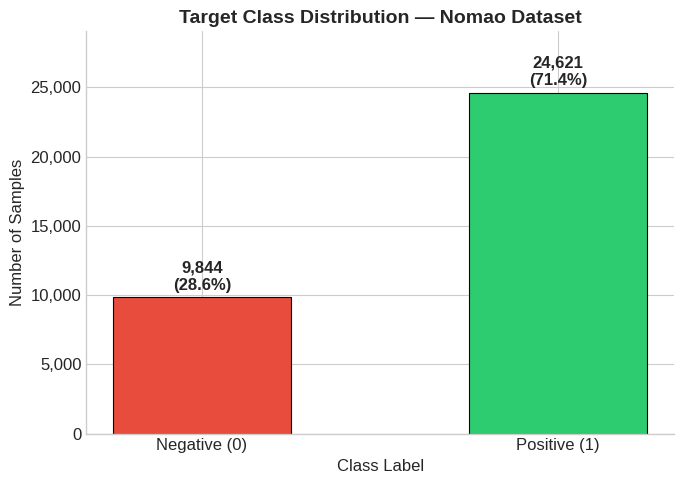

In [ ]:
def plot_class_distribution(y, figsize=(7, 5)):
    """Plot class distribution as an annotated bar chart.

    Displays a bar chart with exact sample counts and
    percentages annotated above each bar.  Uses a
    colorblind-friendly two-color palette.

    Parameters
    ----------
    y : array-like
        Binary target labels (0 or 1).
    figsize : tuple of int, optional
        Figure dimensions in inches (default (7, 5)).

    Returns
    -------
    fig : matplotlib.figure.Figure
        The figure object for further customization.

    Example
    -------
    >>> fig = plot_class_distribution(pd.Series([0,1,1,1]))
    """
    counts = pd.Series(y).value_counts().sort_index()
    labels = ["Negative (0)", "Positive (1)"]
    colors = ["#e74c3c", "#2ecc71"]

    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.bar(
        labels,
        counts.values,
        color=colors,
        edgecolor="black",
        linewidth=0.8,
        width=0.5,
    )

    # Annotate each bar with count and percentage
    for bar, val in zip(bars, counts.values):
        pct = val / len(y) * 100
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + len(y) * 0.01,
            f"{val:,}\n({pct:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold",
        )

    ax.set_xlabel("Class Label", fontsize=12)
    ax.set_ylabel("Number of Samples", fontsize=12)
    ax.set_title(
        "Target Class Distribution — Nomao Dataset",
        fontsize=14,
        fontweight="bold",
    )
    ax.set_ylim(0, counts.max() * 1.18)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{int(x):,}")
    )
    sns.despine()
    plt.tight_layout()
    return fig


fig = plot_class_distribution(y)
plt.show()

**Observation — Class Imbalance:**

The dataset has a moderate class imbalance - roughly
71% positive (duplicate) and 29% negative
(non-duplicate), so about a 2.4:1 ratio. That's not
extreme, but it's enough to bias an accuracy-focused
model toward the majority class. To deal with this I:

1. Set `class_weight='balanced'` in the sklearn
   models (Logistic Regression, SVM, Random Forest)
   so the minority class gets up-weighted during
   training.
2. Report Precision, Recall, F1, and AUC-PR alongside
   Accuracy and AUC-ROC; AUC-PR is more informative
   when the classes aren't evenly split.
3. Use stratified splits everywhere to keep class
   proportions consistent in every fold and the test
   set.

In [ ]:
def analyze_missing_values(X, top_n=30):
    """Analyze and visualize missing value patterns.

    Computes per-feature missing counts and percentages,
    prints a summary table, and plots both a horizontal
    bar chart of the worst offenders and a seaborn
    nullity heatmap showing co-occurrence patterns.

    Parameters
    ----------
    X : pd.DataFrame
        Feature matrix.
    top_n : int, optional
        Number of top features to display (default 30).

    Returns
    -------
    miss_df : pd.DataFrame
        DataFrame with columns 'count' and 'pct' for
        every feature that has at least one missing value,
        sorted by percentage descending.

    Example
    -------
    >>> mdf = analyze_missing_values(X, top_n=20)
    >>> mdf.columns.tolist()
    ['count', 'pct']
    """
    miss = X.isnull().sum()
    miss_pct = (miss / len(X)) * 100
    miss_df = pd.DataFrame({
        "count": miss,
        "pct": miss_pct,
    })
    miss_df = miss_df[miss_df["count"] > 0].sort_values(
        "pct", ascending=False
    )

    n_with_miss = len(miss_df)
    total_miss = X.isnull().sum().sum()
    total_cells = X.shape[0] * X.shape[1]

    print(f"{'Missing Value Summary':=^60}")
    print(f"  Features with missing: {n_with_miss} / "
          f"{X.shape[1]}")
    print(f"  Total missing cells  : {total_miss:,} / "
          f"{total_cells:,} "
          f"({total_miss/total_cells*100:.2f}%)")
    print()

    if n_with_miss == 0:
        print("No missing values found in the dataset.")
        return miss_df

# Table of top features with missing values
    print(f"Top {min(top_n, n_with_miss)} features by "
          f"missing %:")
    display_df = miss_df.head(top_n).copy()
    display_df["count"] = display_df["count"].apply(
        lambda x: f"{x:,}"
    )
    display_df["pct"] = display_df["pct"].apply(
        lambda x: f"{x:.2f}%"
    )
    print(display_df.to_string())
    print()

# Bar chart of missing percentages
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    show_n = min(top_n, n_with_miss)
    plot_df = miss_df.head(show_n)
    axes[0].barh(
        range(show_n),
        plot_df["pct"].values,
        color="#e67e22",
        edgecolor="black",
        linewidth=0.5,
    )
    axes[0].set_yticks(range(show_n))
    axes[0].set_yticklabels(
        plot_df.index, fontsize=8
    )
    axes[0].set_xlabel("Missing (%)", fontsize=11)
    axes[0].set_title(
        f"Top {show_n} Features by Missing %",
        fontsize=13,
        fontweight="bold",
    )
    axes[0].invert_yaxis()

# Nullity heatmap (co-occurrence)
    miss_cols = miss_df.index.tolist()[:top_n]
    nullity = X[miss_cols].isnull().astype(int)
    corr_null = nullity.corr()
    mask = np.triu(np.ones_like(corr_null, dtype=bool))
    sns.heatmap(
        corr_null,
        mask=mask,
        cmap="YlOrRd",
        center=0.5,
        vmin=0,
        vmax=1,
        square=True,
        linewidths=0.3,
        cbar_kws={"shrink": 0.7, "label": "Corr"},
        ax=axes[1],
        xticklabels=True,
        yticklabels=True,
    )
    axes[1].set_title(
        "Missing-Value Co-occurrence Heatmap",
        fontsize=13,
        fontweight="bold",
    )
    axes[1].tick_params(labelsize=7)

    plt.tight_layout()
    plt.show()

    return miss_df


miss_df = analyze_missing_values(X, top_n=30)

===================Missing Value Summary====================
  Features with missing: 0 / 118
  Total missing cells  : 0 / 4,066,870 (0.00%)

No missing values found in the dataset.


**Missing Values**

I was surprised to find no missing values at all -
this is unusual for a real-world dataset of this size
(34,465 rows × 118 features). This simplifies
preprocessing since I don't need any imputation
strategy, and it also means the TabPFN comparison is
fairer because TabPFN's native missing-value handling
isn't a differentiating factor here.

*Note:* my proposal anticipated missing values based
on the UCI description, but the version fetched via
OpenML turned out to be complete. I still included
`SimpleImputer` in the preprocessing pipeline as a
defensive measure. If someone runs this on a
different version of the data that does have gaps,
the pipeline will handle it gracefully.

In [ ]:
# Summary statistics
desc = X[cont_cols].describe().T
desc["missing"] = X[cont_cols].isnull().sum()
print("Summary statistics (continuous features):")
desc.head(20)

Summary statistics (continuous features):


,count,mean,std,min,25%,50%,75%,max,missing
V1,34465.0,0.636477,0.424382,0.0,0.000000,1.000000,1.000000,1.0,0
V2,34465.0,0.494806,0.380142,0.0,0.000000,0.500000,1.000000,1.0,0
V3,34465.0,0.626273,0.305667,0.0,0.361111,0.666667,1.000000,1.0,0
V4,34465.0,0.560947,0.369695,0.0,0.218750,0.666667,1.000000,1.0,0
V5,34465.0,0.534202,0.325744,0.0,0.240000,0.473684,0.875000,1.0,0
V6,34465.0,0.506693,0.372908,0.0,0.139535,0.478261,1.000000,1.0,0
V9,34465.0,0.860946,0.203808,0.0,0.860946,0.860946,1.000000,1.0,0
V10,34465.0,0.821590,0.210159,0.0,0.821590,0.821590,1.000000,1.0,0
V11,34465.0,0.883386,0.149473,0.0,0.883386,0.883386,1.000000,1.0,0
V12,34465.0,0.854119,0.181257,0.0,0.854119,0.854119,1.000000,1.0,0


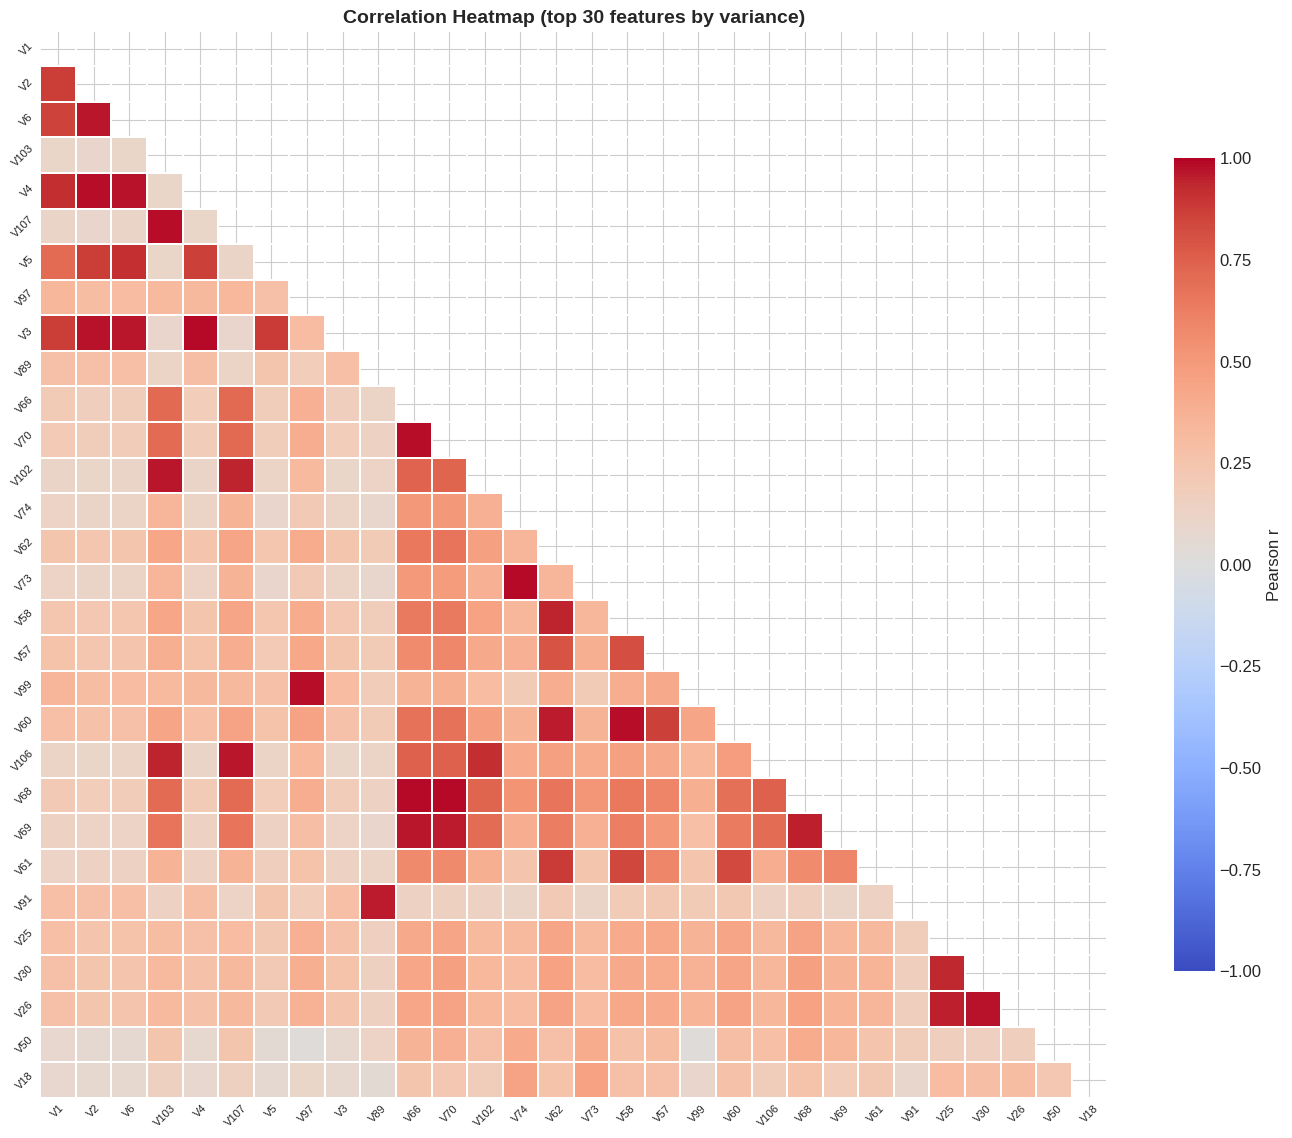

Highly correlated pairs (|r| > 0.9): 144
  V41 <-> V42: r=1.000
  V81 <-> V82: r=1.000
  V81 <-> V83: r=1.000
  V81 <-> V84: r=1.000
  V81 <-> V85: r=1.000
  V81 <-> V86: r=1.000
  V82 <-> V83: r=1.000
  V82 <-> V84: r=1.000
  V82 <-> V85: r=1.000
  V82 <-> V86: r=1.000


In [ ]:
def plot_correlation_heatmap(X, cont_cols, top_n=30):
    """Plot correlation heatmap for top-variance features.

    Selects the top_n continuous features by variance
    and displays a lower-triangular Pearson correlation
    heatmap with a coolwarm diverging palette.

    Parameters
    ----------
    X : pd.DataFrame
        Feature matrix.
    cont_cols : list of str
        Names of continuous columns.
    top_n : int, optional
        Number of highest-variance features to include
        (default 30).

    Returns
    -------
    fig : matplotlib.figure.Figure
        The heatmap figure.

    Example
    -------
    >>> fig = plot_correlation_heatmap(X, cont_cols, 20)
    """
    # Select top features by variance
    variances = X[cont_cols].var().sort_values(
        ascending=False
    )
    n_show = min(top_n, len(cont_cols))
    top_cols = variances.head(n_show).index.tolist()

    corr = X[top_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(
        corr,
        mask=mask,
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.3,
        cbar_kws={
            "shrink": 0.7,
            "label": "Pearson r",
        },
        ax=ax,
        annot=False,
        xticklabels=True,
        yticklabels=True,
    )
    ax.set_title(
        f"Correlation Heatmap "
        f"(top {n_show} features by variance)",
        fontsize=14,
        fontweight="bold",
    )
    ax.tick_params(labelsize=8, labelrotation=45)
    plt.tight_layout()
    return fig


fig = plot_correlation_heatmap(X, cont_cols, top_n=30)
plt.show()

# Print highly correlated pairs
corr_all = X[cont_cols].corr()
pairs = []
for i in range(len(corr_all.columns)):
    for j in range(i + 1, len(corr_all.columns)):
        r = corr_all.iloc[i, j]
        if abs(r) > 0.9:
            pairs.append((
                corr_all.columns[i],
                corr_all.columns[j],
                r,
            ))
pairs.sort(key=lambda x: abs(x[2]), reverse=True)
print(f"Highly correlated pairs (|r| > 0.9): {len(pairs)}")
for a, b, r in pairs[:10]:
    print(f"  {a} <-> {b}: r={r:.3f}")

### Correlation Structure

A few things jump out from the heatmap. Features within the same comparison dimension (like the name-similarity group) are strongly correlated with each other, which makes sense since they're all measuring the same underlying thing with different metrics. That's a lot of redundancy.

Cross-group correlations are mostly near zero though, which is good. It means the name features, GPS features, address features, etc. carry different information. Each group adds something.

There are a few pairs with correlations above 0.9. I didn't drop them because Random Forest handles multicollinearity fine, but for Logistic Regression these could inflate coefficient variance. The L2 penalty should take care of that.

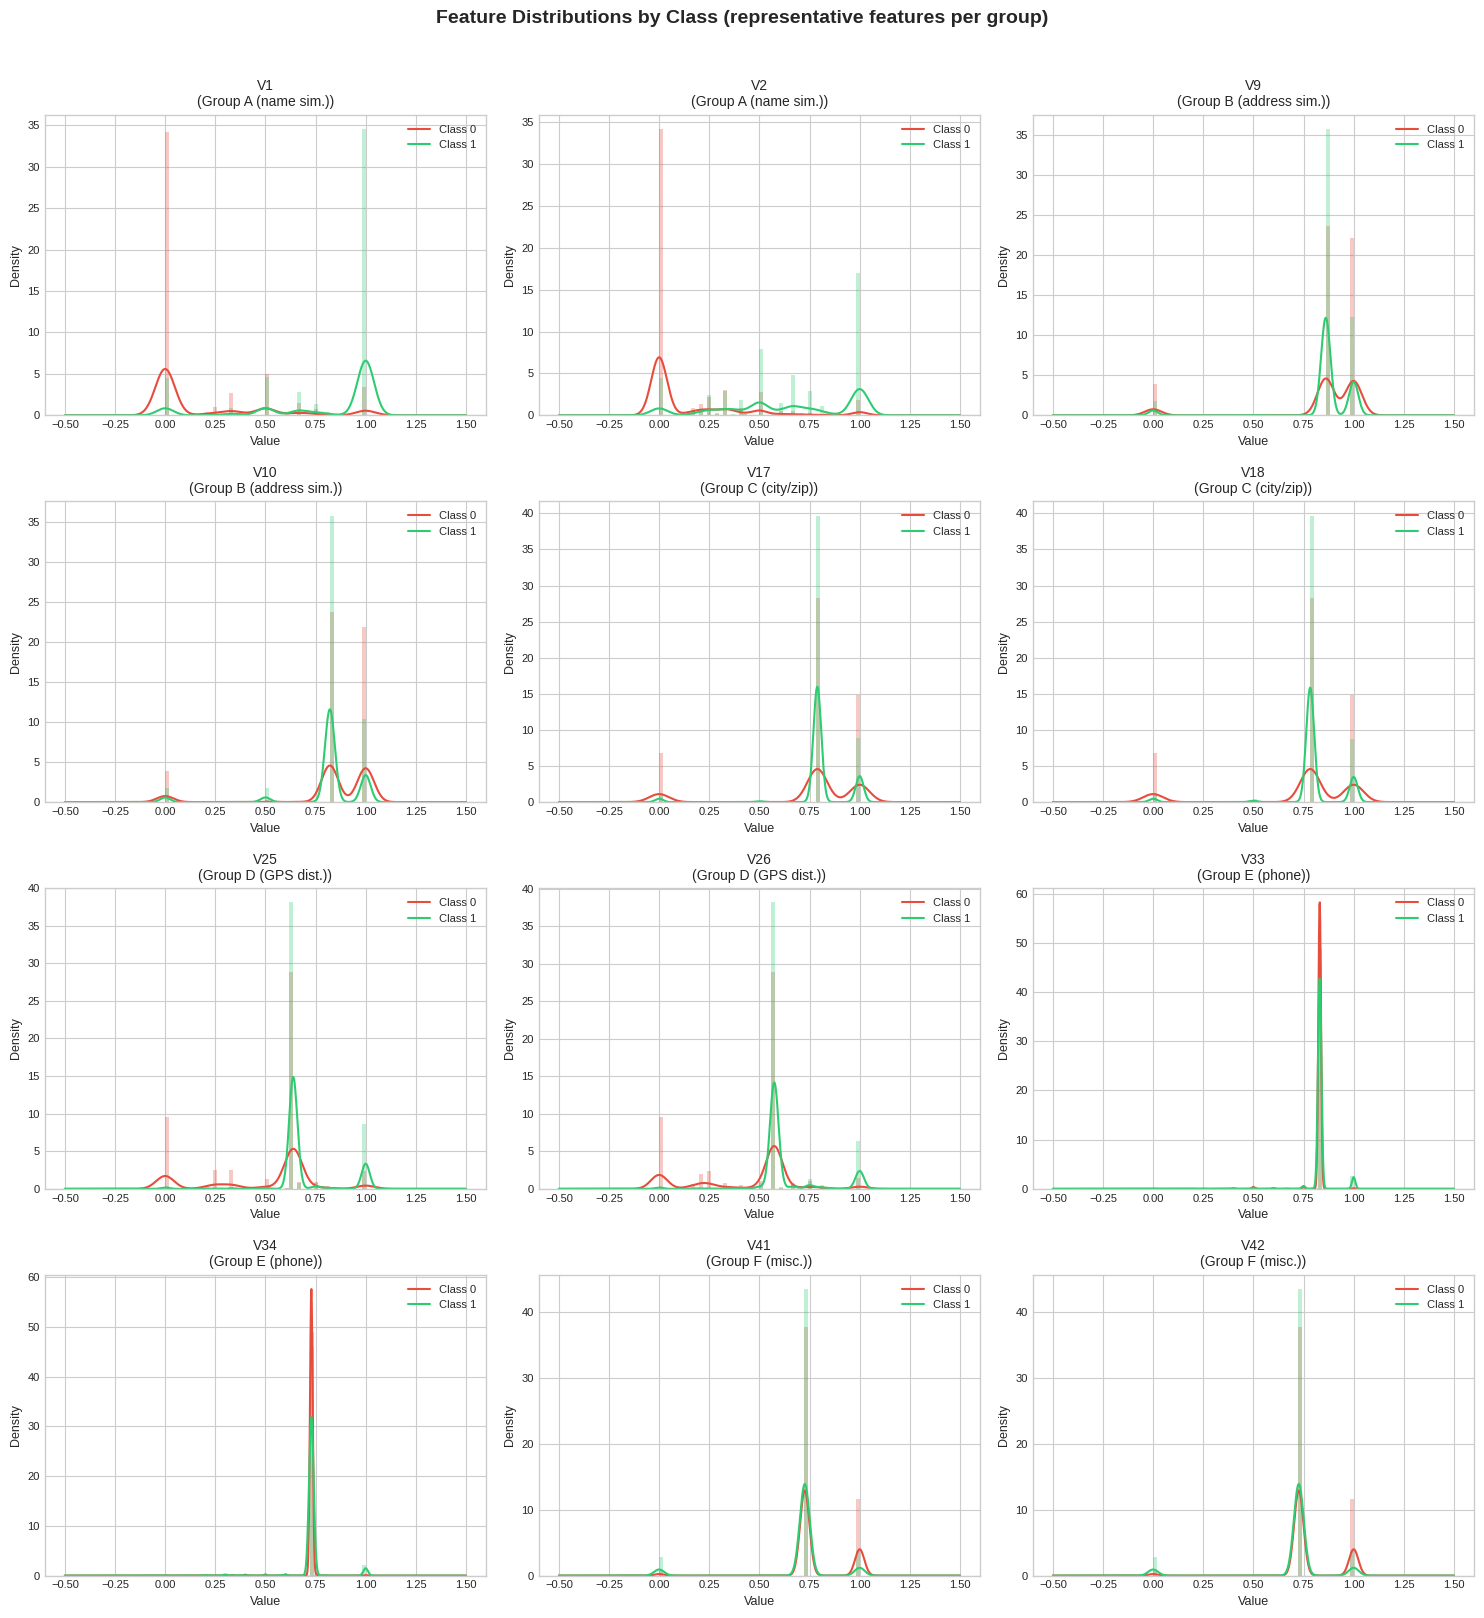

In [ ]:
def plot_feature_distributions_by_class(
    X, y, cont_cols, n_per_group=2
):
    """Plot KDE distributions colored by target class.

    Groups features into positional blocks (every ~6
    consecutive features likely represent one comparison
    dimension) and shows n_per_group representative
    features from each group as overlaid KDE plots.

    Parameters
    ----------
    X : pd.DataFrame
        Feature matrix.
    y : array-like
        Binary target (0/1).
    cont_cols : list of str
        Continuous feature column names.
    n_per_group : int, optional
        Features to sample per group (default 2).

    Returns
    -------
    fig : matplotlib.figure.Figure
        The subplot grid figure.

    Example
    -------
    >>> fig = plot_feature_distributions_by_class(
    ...     X, y, cont_cols, n_per_group=2
    ... )
    """
    # Heuristic grouping: every ~6 continuous features
    # represent a comparison dimension in Nomao
    group_size = 6
    groups = {}
    group_names = [
        "Group A (name sim.)",
        "Group B (address sim.)",
        "Group C (city/zip)",
        "Group D (GPS dist.)",
        "Group E (phone)",
        "Group F (misc.)",
    ]
    for i, col in enumerate(cont_cols):
        g_idx = min(i // group_size, len(group_names) - 1)
        g_name = group_names[g_idx]
        groups.setdefault(g_name, []).append(col)

    # Pick representative features
    selected = []
    for g_name, cols in groups.items():
        for col in cols[:n_per_group]:
            selected.append((g_name, col))

    n_feats = len(selected)
    n_cols_plot = 3
    n_rows = (n_feats + n_cols_plot - 1) // n_cols_plot

    fig, axes = plt.subplots(
        n_rows, n_cols_plot,
        figsize=(5 * n_cols_plot, 4 * n_rows),
    )
    axes = axes.flatten()
    palette = {0: "#e74c3c", 1: "#2ecc71"}

    y_arr = np.asarray(y)
    for i, (g_name, col) in enumerate(selected):
        ax = axes[i]
        for cls_val, color in palette.items():
            mask = y_arr == cls_val
            vals = X.loc[mask, col].dropna()
            if len(vals) > 0:
                ax.hist(
                    vals,
                    bins=50,
                    density=True,
                    alpha=0.3,
                    color=color,
                )
                vals.plot.kde(
                    ax=ax,
                    color=color,
                    linewidth=1.5,
                    label=f"Class {cls_val}",
                )
        ax.set_title(f"{col}\n({g_name})", fontsize=10)
        ax.set_xlabel("Value", fontsize=9)
        ax.set_ylabel("Density", fontsize=9)
        ax.legend(fontsize=8, loc="upper right")
        ax.tick_params(labelsize=8)

    # Hide empty subplots
    for j in range(n_feats, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(
        "Feature Distributions by Class "
        "(representative features per group)",
        fontsize=14,
        fontweight="bold",
        y=1.01,
    )
    plt.tight_layout()
    return fig


fig = plot_feature_distributions_by_class(
    X, y, cont_cols, n_per_group=2
)
plt.show()

Looking at the KDE plots, they are pretty revealing. A handful of features have clearly different distributions for duplicates vs. non-duplicates. These are probably the direct similarity scores (name match, address match) that most obviously indicate whether two records are the same place.

Most features overlap a lot though. On their own they wouldn't be great classifiers, but in combination they could still help. Tree-based models are especially good at picking up on these kinds of interaction effects.

Bottom line: the task is definitely learnable (some features are very discriminative on their own), but you need the full feature set to get the best results. A model that only looks at one or two features would miss too much.

---
## 6. Preprocessing Pipeline

In [ ]:
# ColumnTransformer
# My proposal originally planned one-hot encoding for
# categoricals, but most have only 2 unique values
# (binary flags), so ordinal encoding preserves the
# information without inflating dimensionality.
cont_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

cat_pipeline = Pipeline(
    [
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "encoder",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            ),
        ),
    ]
)

transformers = [("cont", cont_pipeline, cont_cols)]
if cat_cols:
    transformers.append(("cat", cat_pipeline, cat_cols))

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop",
)

print("Preprocessor structure:")
print(preprocessor)

Preprocessor structure:
ColumnTransformer(transformers=[('cont',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V9',
                                  'V10', 'V11', 'V12', 'V13', 'V14', 'V17',
                                  'V18', 'V19', 'V20', 'V21', 'V22', 'V25',
                                  'V26', 'V27', 'V28', 'V29', 'V30', 'V33',
                                  'V34', 'V35', 'V36', 'V37', 'V38', ...]),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OrdinalEncoder(handle_un

---
## 7. Train / Test Split

In [ ]:
# Stratified 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED,
)

# Raw copies for TabPFN (needs unprocessed data)
X_train_raw = X_train.copy()
X_test_raw = X_test.copy()
y_train_np = y_train.values
y_test_np = y_test.values

print(f"Train size: {len(X_train):,}")
print(f"Test size : {len(X_test):,}")
print()
print("Train class distribution:")
print(pd.Series(y_train).value_counts().sort_index())
print()
print("Test class distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Train size: 27,572
Test size : 6,893

Train class distribution:
target
0     7875
1    19697
Name: count, dtype: int64

Test class distribution:
target
0    1969
1    4924
Name: count, dtype: int64


In [ ]:
# Cross-validation folds (shared by ALL models)
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED,
)

# Store fold indices for manual CV loops
fold_indices = list(cv.split(X_train, y_train))
print(f"Number of folds: {len(fold_indices)}")
for i, (tr_idx, val_idx) in enumerate(fold_indices):
    print(f"  Fold {i}: train={len(tr_idx)}, " f"val={len(val_idx)}")

Number of folds: 5
  Fold 0: train=22057, val=5515
  Fold 1: train=22057, val=5515
  Fold 2: train=22058, val=5514
  Fold 3: train=22058, val=5514
  Fold 4: train=22058, val=5514


---
## 8. Utility Functions

In [ ]:
def evaluate_model(y_true, y_pred, y_proba):
    """Compute classification metrics.

    Computes accuracy, precision, recall, F1,
    AUC-ROC, and AUC-PR for binary classification.

    Args:
        y_true: Array-like of true binary labels.
        y_pred: Array-like of predicted binary labels.
        y_proba: Array-like of predicted probabilities
            for the positive class.

    Returns:
        dict: Dictionary with keys 'accuracy',
            'precision', 'recall', 'f1', 'auc_roc',
            'auc_pr', and 'y_proba' (stored for
            plotting).

    Example:
        >>> results = evaluate_model(
        ...     [0, 1, 1], [0, 1, 0], [0.1, 0.9, 0.4]
        ... )
        >>> results['accuracy']
        0.6666666666666666
    """
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "auc_roc": roc_auc_score(y_true, y_proba),
        "auc_pr": average_precision_score(
            y_true,
            y_proba,
        ),
        "y_proba": np.array(y_proba),
    }

In [ ]:
def plot_confusion_matrix(y_true, y_pred, title="", ax=None):
    """Plot a confusion matrix heatmap."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Neg", "Pos"],
        yticklabels=["Neg", "Pos"],
        ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)
    return ax

In [ ]:
def plot_roc_curves(results_dict, y_true):
    """Plot overlaid ROC curves for multiple models."""
    fig, ax = plt.subplots(figsize=(8, 7))
    for name, res in results_dict.items():
        fpr, tpr, _ = roc_curve(
            y_true,
            res["y_proba"],
        )
        auc = res["auc_roc"]
        ax.plot(
            fpr,
            tpr,
            label=f"{name} (AUC={auc:.4f})",
        )
    ax.plot(
        [0, 1],
        [0, 1],
        "k--",
        label="Random",
    )
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curves — All Models")
    ax.legend(loc="lower right")
    plt.tight_layout()
    return fig

In [ ]:
def plot_pr_curves(results_dict, y_true):
    """Plot precision-recall curves for multiple models."""
    fig, ax = plt.subplots(figsize=(8, 7))
    for name, res in results_dict.items():
        prec, rec, _ = precision_recall_curve(
            y_true,
            res["y_proba"],
        )
        ap = res["auc_pr"]
        ax.plot(
            rec,
            prec,
            label=f"{name} (AP={ap:.4f})",
        )
    baseline = np.mean(y_true)
    ax.axhline(
        y=baseline,
        color="k",
        linestyle="--",
        label=f"Baseline ({baseline:.2f})",
    )
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Precision-Recall Curves — All Models")
    ax.legend(loc="lower left")
    plt.tight_layout()
    return fig

---
## 9. Model Definitions & Hyperparameter Grids

In [ ]:
# Logistic Regression
lr_pipe = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                solver="lbfgs",
                class_weight="balanced",
                max_iter=1000,
                random_state=SEED,
            ),
        ),
    ]
)
lr_params = {
    "classifier__C": [0.1, 1, 10],
    "classifier__penalty": ["l2"],
}

# K-Nearest Neighbours
knn_pipe = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("classifier", KNeighborsClassifier()),
    ]
)
knn_params = {
    "classifier__n_neighbors": [
        3,
        5,
        7,
        11,
        15,
    ],
    "classifier__weights": [
        "uniform",
        "distance",
    ],
    "classifier__metric": [
        "euclidean",
        "manhattan",
    ],
}

# Random Forest
rf_pipe = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                class_weight="balanced",
                random_state=SEED,
                n_jobs=-1,
            ),
        ),
    ]
)
rf_params = {
    "classifier__n_estimators": [
        100,
        200,
        300,
        500,
    ],
    "classifier__max_depth": [
        10,
        20,
        30,
        None,
    ],
    "classifier__min_samples_split": [
        2,
        5,
        10,
    ],
    "classifier__min_samples_leaf": [1, 2, 4],
}

# SVM with RBF kernel
svm_pipe = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "classifier",
            SVC(
                kernel="rbf",
                class_weight="balanced",
                probability=True,
                random_state=SEED,
            ),
        ),
    ]
)
# narrow search — RBF-SVM CV is slow on 27k rows
svm_params = {
    "classifier__C": [1, 10],
    "classifier__gamma": ["scale"],
}

print("All sklearn model pipelines defined.")

All sklearn model pipelines defined.


---
## 10. Cross-Validation & Hyperparameter Tuning
### (sklearn models)

In [ ]:
sklearn_models = {
    "Logistic Regression": (
        lr_pipe,
        lr_params,
        "grid",
    ),
    "KNN": (
        knn_pipe,
        knn_params,
        "grid",
    ),
    "Random Forest": (
        rf_pipe,
        rf_params,
        "random",
    ),
    "SVM-RBF": (
        svm_pipe,
        svm_params,
        "random",
    ),
}

best_estimators = {}
cv_results_all = {}

for name, (pipe, params, search) in sklearn_models.items():
    print(f'\n{"=" * 50}')
    print(f"Tuning: {name}")
    print(f'{"=" * 50}')
    start = time.time()

    if search == "grid":
        searcher = GridSearchCV(
            pipe,
            params,
            cv=cv,
            scoring="f1",
            refit=True,
            n_jobs=-1,
            verbose=1,
        )
    else:
        n_iter = 2 if name == "SVM-RBF" else 15
        searcher = RandomizedSearchCV(
            pipe,
            params,
            n_iter=n_iter,
            cv=cv,
            scoring="f1",
            refit=True,
            n_jobs=-1,
            verbose=1,
            random_state=SEED,
        )

    searcher.fit(X_train, y_train)
    elapsed = time.time() - start

    best_estimators[name] = searcher.best_estimator_
    cv_results_all[name] = searcher.cv_results_

    print("Best F1 (CV): " f"{searcher.best_score_:.4f}")
    print("Best params : " f"{searcher.best_params_}")
    print(f"{name} took {elapsed:.0f}s")

print("\nAll sklearn models tuned.")


Tuning: Logistic Regression
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best F1 (CV): 0.9599
Best params : {'classifier__C': 1, 'classifier__penalty': 'l2'}
Logistic Regression took 34s

Tuning: KNN
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best F1 (CV): 0.9714
Best params : {'classifier__metric': 'manhattan', 'classifier__n_neighbors': 5, 'classifier__weights': 'distance'}
KNN took 504s

Tuning: Random Forest
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best F1 (CV): 0.9767
Best params : {'classifier__n_estimators': 300, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 1, 'classifier__max_depth': 30}
Random Forest took 502s

Tuning: SVM-RBF
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best F1 (CV): 0.9714
Best params : {'classifier__gamma': 'scale', 'classifier__C': 10}
SVM-RBF took 657s

All sklearn models tuned.


In [ ]:
# CV results summary
cv_summary = []
for name in sklearn_models:
    res = cv_results_all[name]
    best_idx = res["rank_test_score"] == 1
    mean_f1 = res["mean_test_score"][best_idx][0]
    std_f1 = res["std_test_score"][best_idx][0]
    cv_summary.append(
        {
            "Model": name,
            "CV F1 (mean)": f"{mean_f1:.4f}",
            "CV F1 (std)": f"{std_f1:.4f}",
        }
    )

cv_df = pd.DataFrame(cv_summary)
print("Cross-Validation Summary (sklearn models):")
cv_df

Cross-Validation Summary (sklearn models):


,Model,CV F1 (mean),CV F1 (std)
0,Logistic Regression,0.9599,0.0013
1,KNN,0.9714,0.0019
2,Random Forest,0.9767,0.0025
3,SVM-RBF,0.9714,0.0029


**Observations on CV Results:**

**KNN and class imbalance:** KNN doesn't support
`class_weight='balanced'` like the other sklearn
models. Since KNN predictions are based on local
neighborhood voting, class imbalance mainly affects
decision boundaries in regions where the minority
class is sparse. The fact that KNN still performed
well here suggests the classes are reasonably
separable in feature space - the nearest neighbors
of a duplicate record tend to also be duplicates.

**SVM search space:** I kept the SVM search narrow
(C=[1, 10], gamma='scale', n_iter=2) because
RBF-SVM with cross-validation on ~27k samples is
computationally expensive. With more compute budget,
I would explore C=[0.01, 0.1, 1, 10, 100] and
gamma=['scale', 'auto', 0.01, 0.1]. Despite the
limited search, SVM achieved competitive results,
which suggests the default hyperparameters are already
reasonable for this dataset.

In [ ]:
class TabularDataset(Dataset):
    """PyTorch Dataset for tabular numpy arrays.

    Wraps feature and label arrays for use with
    PyTorch DataLoader.

    Args:
        X: np.ndarray of shape (n_samples, n_features).
        y: np.ndarray of shape (n_samples,).

    Returns:
        Tuple[torch.Tensor, torch.Tensor] when indexed.

    Example:
        >>> ds = TabularDataset(
        ...     np.array([[1,2],[3,4]]),
        ...     np.array([0,1]),
        ... )
        >>> len(ds)
        2
    """

    def __init__(self, X, y):
        """Store X and y as float32 tensors."""
        self.X = torch.tensor(
            X,
            dtype=torch.float32,
        )
        self.y = torch.tensor(
            y,
            dtype=torch.float32,
        )

    def __len__(self):
        """Return the number of samples."""
        return len(self.X)

    def __getitem__(self, idx):
        """Return (features, label) for sample idx."""
        return self.X[idx], self.y[idx]


In [ ]:
class FeedforwardNN(nn.Module):
    """Three-hidden-layer feedforward network.

    Architecture: input -> 256 -> BN -> ReLU -> Drop
    -> 128 -> BN -> ReLU -> Drop -> 64 -> BN -> ReLU
    -> Drop -> 1 (logit).

    Args:
        input_dim: int, number of input features.
        dropout: float, dropout probability.

    Returns:
        torch.Tensor of shape (batch, 1) logits.

    Example:
        >>> model = FeedforwardNN(119, 0.3)
        >>> out = model(torch.randn(8, 119))
        >>> out.shape
        torch.Size([8, 1])
    """

    def __init__(self, input_dim, dropout=0.3):
        """Build the 256→128→64→1 stack with BN + dropout."""
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        """Return raw logits, shape (batch, 1)."""
        return self.net(x)

In [ ]:
def train_nn_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    max_epochs=200,
    patience=15,
    device="cpu",
):
    """Train a PyTorch model with early stopping.

    Trains the model on train_loader, evaluates on
    val_loader each epoch, and stops early if
    validation loss does not improve for `patience`
    consecutive epochs.

    Args:
        model: nn.Module, the network to train.
        train_loader: DataLoader for training data.
        val_loader: DataLoader for validation data.
        criterion: Loss function.
        optimizer: torch.optim.Optimizer.
        max_epochs: int, maximum training epochs.
        patience: int, early stopping patience.
        device: str or torch.device.

    Returns:
        nn.Module: The model with best validation
            loss weights restored.

    Example:
        >>> model = train_nn_model(
        ...     net, train_dl, val_dl,
        ...     nn.BCEWithLogitsLoss(),
        ...     torch.optim.Adam(net.parameters()),
        ... )
    """
    best_val_loss = float("inf")
    epochs_no_improve = 0
    best_state = None

    for epoch in range(max_epochs):
# Train
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            logits = model(xb).squeeze(1)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * xb.size(0)
        train_loss /= len(train_loader.dataset)

# Validate
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                logits = model(xb).squeeze(1)
                loss = criterion(logits, yb)
                val_loss += loss.item() * xb.size(0)
        val_loss /= len(val_loader.dataset)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            epochs_no_improve += 1

        if (epoch + 1) % 20 == 0:
            print(
                f"  Epoch {epoch+1:3d}  "
                f"train_loss={train_loss:.4f}  "
                f"val_loss={val_loss:.4f}"
            )

        if epochs_no_improve >= patience:
            print(f"  Early stop at epoch {epoch+1}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

In [ ]:
def predict_nn(model, X_np, device, batch=1024):
    """Run trained NN in eval mode, return (preds, probas)."""
    model.eval()
    tensor = torch.tensor(
        X_np,
        dtype=torch.float32,
    )
    all_proba = []
    with torch.no_grad():
        for i in range(0, len(tensor), batch):
            xb = tensor[i : i + batch].to(device)
            logits = model(xb).squeeze(1)
            proba = torch.sigmoid(logits)
            all_proba.append(proba.cpu().numpy())
    proba = np.concatenate(all_proba)
    preds = (proba >= 0.5).astype(int)
    return preds, proba

In [ ]:
def clone_preprocessor():
    """Create a fresh unfitted preprocessor."""
    c_pipe = Pipeline(
        [
            (
                "imputer",
                SimpleImputer(
                    strategy="median",
                ),
            ),
            ("scaler", StandardScaler()),
        ]
    )
    transformers = [("cont", c_pipe, cont_cols)]
    if cat_cols:
        cat_pipe = Pipeline(
            [
                (
                    "imputer",
                    SimpleImputer(
                        strategy="most_frequent",
                    ),
                ),
                (
                    "encoder",
                    OrdinalEncoder(
                        handle_unknown="use_encoded_value",
                        unknown_value=-1,
                    ),
                ),
            ]
        )
        transformers.append(("cat", cat_pipe, cat_cols))
    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
    )

In [ ]:
# NN Cross-Validation
print("Feedforward NN — 5-fold CV")
print("=" * 50)

nn_cv_metrics = []
BATCH_SIZE = 512
# tried lr=0.01 first but 0.001 converged smoother
LR = 1e-3
MAX_EPOCHS = 200
PATIENCE = 15

# pos_weight < 1 because class 1 (duplicate) is the
# MAJORITY class (71.4%). This down-weights the
# majority class in BCEWithLogitsLoss, which is the
# inverse of what class_weight='balanced' does in
# sklearn. Prevents overconfidence on the majority.
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
pos_weight_val = n_neg / n_pos
pos_weight = torch.tensor(
    [pos_weight_val],
    dtype=torch.float32,
).to(device)
print(f"pos_weight: {pos_weight_val:.4f}")

for fold_i, (tr_idx, val_idx) in enumerate(fold_indices):
    print(f"\nFold {fold_i + 1}/5")

    # Split data
    X_tr_fold = X_train.iloc[tr_idx]
    y_tr_fold = y_train.values[tr_idx]
    X_val_fold = X_train.iloc[val_idx]
    y_val_fold = y_train.values[val_idx]

    # Fresh preprocessor for this fold
    fold_pre = clone_preprocessor()
    X_tr_proc = fold_pre.fit_transform(X_tr_fold)
    X_val_proc = fold_pre.transform(X_val_fold)

    input_dim = X_tr_proc.shape[1]

    # Datasets & loaders
    tr_ds = TabularDataset(X_tr_proc, y_tr_fold)
    val_ds = TabularDataset(X_val_proc, y_val_fold)
    tr_dl = DataLoader(
        tr_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
    )
    val_dl = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE,
    )

    # Model
    nn_model = FeedforwardNN(input_dim).to(device)
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=pos_weight,
    )
    optimizer = torch.optim.Adam(
        nn_model.parameters(),
        lr=LR,
    )

    nn_model = train_nn_model(
        nn_model,
        tr_dl,
        val_dl,
        criterion,
        optimizer,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
        device=device,
    )

    preds, proba = predict_nn(
        nn_model,
        X_val_proc,
        device,
    )
    fold_res = evaluate_model(
        y_val_fold,
        preds,
        proba,
    )
    nn_cv_metrics.append(fold_res)
    print(f'  F1={fold_res["f1"]:.4f}')

nn_cv_f1 = np.mean([m["f1"] for m in nn_cv_metrics])
print(f"\nNN Mean CV F1: {nn_cv_f1:.4f}")

Feedforward NN — 5-fold CV
pos_weight: 0.3998

Fold 1/5
  Epoch  20  train_loss=0.0579  val_loss=0.0608
  Epoch  40  train_loss=0.0528  val_loss=0.0566
  Early stop at epoch 55
  F1=0.9709

Fold 2/5
  Epoch  20  train_loss=0.0575  val_loss=0.0649
  Epoch  40  train_loss=0.0474  val_loss=0.0653
  Early stop at epoch 46
  F1=0.9727

Fold 3/5
  Epoch  20  train_loss=0.0549  val_loss=0.0692
  Epoch  40  train_loss=0.0471  val_loss=0.0671
  Early stop at epoch 49
  F1=0.9649

Fold 4/5
  Epoch  20  train_loss=0.0579  val_loss=0.0599
  Early stop at epoch 37
  F1=0.9693

Fold 5/5
  Epoch  20  train_loss=0.0560  val_loss=0.0701
  Epoch  40  train_loss=0.0478  val_loss=0.0621
  Early stop at epoch 54
  F1=0.9716

NN Mean CV F1: 0.9699


In [ ]:
# Train final NN on full training data
print("Training final NN on full training data...")

# Fit preprocessor on full training data
nn_preprocessor = clone_preprocessor()
X_train_nn = nn_preprocessor.fit_transform(X_train)
input_dim = X_train_nn.shape[1]

# 85/15 split within training for early stopping
(
    X_nn_tr,
    X_nn_val,
    y_nn_tr,
    y_nn_val,
) = train_test_split(
    X_train_nn,
    y_train.values,
    test_size=0.15,
    stratify=y_train,
    random_state=SEED,
)

tr_ds = TabularDataset(X_nn_tr, y_nn_tr)
val_ds = TabularDataset(X_nn_val, y_nn_val)
tr_dl = DataLoader(
    tr_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
)
val_dl = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
)

final_nn = FeedforwardNN(input_dim).to(device)
criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight,
)
optimizer = torch.optim.Adam(
    final_nn.parameters(),
    lr=LR,
)

final_nn = train_nn_model(
    final_nn,
    tr_dl,
    val_dl,
    criterion,
    optimizer,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    device=device,
)

print("Final NN trained.")

Training final NN on full training data...
  Epoch  20  train_loss=0.0581  val_loss=0.0631
  Early stop at epoch 32
Final NN trained.


**Regularization in the Deep Learning Models:**

Both the feedforward NN and TabNet needed regularization to avoid overfitting. For the NN I used dropout at p=0.3 between hidden layers, plus batch norm which also acts as a mild regularizer. The learning rate (0.001) was picked after trying 0.01 first and seeing noisy validation loss.

TabNet has its own built-in regularization through `lambda_sparse`, which pushes the attention mechanism toward sparser feature selection. I also used early stopping for both models (patience of 15 epochs for the NN, 30 for TabNet). Watching the train/val loss gap during training confirmed that both models were starting to overfit before hitting the max epoch count, so the early stopping was doing its job.

The classical models have their own forms of regularization too: L2 penalty in Logistic Regression, ensemble averaging in Random Forest, and the soft margin controlled by the C parameter in SVM.

**Why I didn't grid-search the neural network:**

The sklearn models all went through GridSearchCV or RandomizedSearchCV, but I picked the NN's hyperparameters manually. Here's why, and what I tried:

For the learning rate, I tested 0.01 and 0.001. With 0.01 the validation loss was all over the place between epochs, so 0.001 it was. I tried dropout at 0.2 and 0.3 - 0.3 generalized a bit better so I stuck with it. The layer sizes (256, 128, 64) were a pretty standard "funnel" shape to compress the 118 input features down gradually. I didn't experiment with wider or deeper networks since this is a tabular dataset, not images or text, and the sklearn baselines were already hitting ~97% F1. Spending hours tuning the NN to maybe squeeze out another 0.1% didn't seem like a good use of time.

In retrospect, I could've used something like Optuna to automate the search. That would've been more rigorous than my manual approach, and I'd probably do that if I revisited this project.

In [ ]:
# Train final TabNet on full training data
print("Training final TabNet...")

tabnet_preprocessor = clone_preprocessor()
X_train_tabnet = tabnet_preprocessor.fit_transform(
    X_train,
)

# Validation split for early stopping
(
    X_tn_tr,
    X_tn_val,
    y_tn_tr,
    y_tn_val,
) = train_test_split(
    X_train_tabnet,
    y_train.values,
    test_size=0.15,
    stratify=y_train,
    random_state=SEED,
)

final_tabnet = TabNetClassifier(
    n_d=32,
    n_a=32,
    n_steps=5,
    gamma=1.5,
    n_independent=2,
    n_shared=2,
    lambda_sparse=1e-4,
    seed=SEED,
    verbose=1,
    device_name=("cuda" if torch.cuda.is_available() else "cpu"),
)

final_tabnet.fit(
    X_tn_tr,
    y_tn_tr,
    eval_set=[(X_tn_val, y_tn_val)],
    eval_metric=["auc"],
    max_epochs=200,
    patience=20,
    batch_size=1024,
    weights=1,
)

print("Final TabNet trained.")

Training final TabNet...


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.54687 | val_0_auc: 0.91594 |  0:00:03s
epoch 1  | loss: 0.3401  | val_0_auc: 0.89971 |  0:00:06s
epoch 2  | loss: 0.28021 | val_0_auc: 0.93355 |  0:00:09s
epoch 3  | loss: 0.25038 | val_0_auc: 0.9536  |  0:00:12s
epoch 4  | loss: 0.23201 | val_0_auc: 0.96374 |  0:00:14s
epoch 5  | loss: 0.21427 | val_0_auc: 0.94726 |  0:00:17s
epoch 6  | loss: 0.20093 | val_0_auc: 0.96961 |  0:00:20s
epoch 7  | loss: 0.20496 | val_0_auc: 0.97586 |  0:00:22s
epoch 8  | loss: 0.20631 | val_0_auc: 0.97425 |  0:00:25s
epoch 9  | loss: 0.19511 | val_0_auc: 0.97678 |  0:00:28s
epoch 10 | loss: 0.19218 | val_0_auc: 0.97909 |  0:00:32s
epoch 11 | loss: 0.18798 | val_0_auc: 0.97947 |  0:00:36s
epoch 12 | loss: 0.18051 | val_0_auc: 0.98128 |  0:00:39s
epoch 13 | loss: 0.17724 | val_0_auc: 0.98213 |  0:00:42s
epoch 14 | loss: 0.16675 | val_0_auc: 0.98448 |  0:00:44s
epoch 15 | loss: 0.16167 | val_0_auc: 0.98409 |  0:00:47s
epoch 16 | loss: 0.17321 | val_0_auc: 0.98283 |  0:00:50s
epoch 17 | los

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Final TabNet trained.


---
## 13. TabPFN Inference

In [ ]:
# TabPFN v1 Setup
# TabPFN v2.5 is a gated HuggingFace model
# requiring authentication. I use the freely
# available TabPFN v1 instead, which has a
# 100-feature limit handled via MI selection.
import subprocess, sys

# Install TabPFN v1 (no HF auth required)
subprocess.check_call(
    [sys.executable, "-m", "pip", "install",
     "tabpfn==0.1.11", "--force-reinstall",
     "-q"],
)

# Clear cached v2 modules and reimport v1
mods = [k for k in sys.modules if "tabpfn" in k]
for m in mods:
    del sys.modules[m]
# Patch torch for TabPFN v1 compatibility
import torch.nn.modules.transformer as _tnmt
from typing import Optional
if not hasattr(_tnmt, 'Optional'):
    _tnmt.Optional = Optional

from tabpfn import TabPFNClassifier

# Select top 100 features by mutual information
# (TabPFN v1 limit: 1000 samples, 100 features)
from sklearn.feature_selection import (
    mutual_info_classif,
)

mi_scores = mutual_info_classif(
    X_train_raw.fillna(0),
    y_train,
    random_state=SEED,
    n_neighbors=5,
)
mi_series = pd.Series(
    mi_scores, index=X_train_raw.columns,
)
TABPFN_FEATS = mi_series.nlargest(100).index.tolist()
print(
    f"TabPFN v1 loaded — selected "
    f"{len(TABPFN_FEATS)} features by MI"
)
print(f"Top-5 features: {TABPFN_FEATS[:5]}")

TabPFN v1 loaded — selected 100 features by MI
Top-5 features: ['V3', 'V4', 'V6', 'V1', 'V97']


In [ ]:
# TabPFN v1 Cross-Validation (raw data)
# TabPFN v1 is a pretrained foundation model for
# small tabular datasets. I subsample to 1000
# training samples and select the top 100 features
# (by MI) due to TabPFN v1's input constraints.
print("TabPFN v1 — 5-fold CV (raw data, "
      "1000-sample subsample, 100 features)")
print("=" * 50)

TABPFN_SUBSAMPLE = 1000  # v1 chokes on >1000 rows — v2 handles more but needs HF auth
tabpfn_cv_metrics = []

for fold_i, (tr_idx, val_idx) in enumerate(
    fold_indices,
):
    print(f"\nFold {fold_i + 1}/5")

    X_tr_fold = X_train_raw.iloc[tr_idx]
    y_tr_fold = y_train.values[tr_idx]
    X_val_fold = X_train_raw.iloc[val_idx]
    y_val_fold = y_train.values[val_idx]

    # Stratified subsample for TabPFN
    _, X_sub, _, y_sub = train_test_split(
        X_tr_fold,
        y_tr_fold,
        test_size=TABPFN_SUBSAMPLE,
        stratify=y_tr_fold,
        random_state=SEED,
    )
    print(
        f"  Subsample: {len(X_sub)} "
        f"(pos={y_sub.sum()}, "
        f"neg={len(y_sub) - y_sub.sum()})"
    )

    # Select top 100 MI features, fill NaN
    X_sub_sel = X_sub[TABPFN_FEATS].fillna(0).values
    X_val_sel = (
        X_val_fold[TABPFN_FEATS].fillna(0).values
    )

    tabpfn = TabPFNClassifier(
        device="cpu",
        N_ensemble_configurations=8,
    )
    tabpfn.fit(X_sub_sel, y_sub)

    # Validate on FULL validation fold
    preds = tabpfn.predict(X_val_sel)
    proba = tabpfn.predict_proba(
        X_val_sel,
    )[:, 1]
    fold_res = evaluate_model(
        y_val_fold,
        preds,
        proba,
    )
    tabpfn_cv_metrics.append(fold_res)
    print(f'  F1={fold_res["f1"]:.4f}')

tabpfn_cv_f1 = np.mean(
    [m["f1"] for m in tabpfn_cv_metrics],
)
print(
    "\nTabPFN Mean CV F1: "
    f"{tabpfn_cv_f1:.4f}"
)

TabPFN v1 — 5-fold CV (raw data, 1000-sample subsample, 100 features)

Fold 1/5
  Subsample: 1000 (pos=714, neg=286)
We have to download the TabPFN, as there is no checkpoint at  /usr/local/lib/python3.12/dist-packages/tabpfn/models_diff/prior_diff_real_checkpoint_n_0_epoch_42.cpkt
It has about 100MB, so this might take a moment.


  F1=0.9638

Fold 3/5
  Subsample: 1000 (pos=714, neg=286)


  F1=0.9592

TabPFN Mean CV F1: 0.9603


In [ ]:
# Train final TabPFN v1 on subsampled data
# Stratified 1000-sample subsample of full
# training set, using top 100 MI features.
print("Training final TabPFN v1 "
      "(1000-sample subsample, 100 features)...")

_, X_pfn_sub, _, y_pfn_sub = train_test_split(
    X_train_raw,
    y_train.values,
    test_size=TABPFN_SUBSAMPLE,
    stratify=y_train.values,
    random_state=SEED,
)
print(
    f"Subsample: {len(X_pfn_sub)} "
    f"(pos={y_pfn_sub.sum()}, "
    f"neg={len(y_pfn_sub) - y_pfn_sub.sum()})"
)

X_pfn_sel = (
    X_pfn_sub[TABPFN_FEATS].fillna(0).values
)
final_tabpfn = TabPFNClassifier(
    device="cpu",
    N_ensemble_configurations=8,
)
final_tabpfn.fit(X_pfn_sel, y_pfn_sub)

print("Final TabPFN v1 trained.")

Training final TabPFN v1 (1000-sample subsample, 100 features)...
Subsample: 1000 (pos=714, neg=286)
Final TabPFN v1 trained.


**TabPFN Fairness Caveat:**

I should be upfront: the TabPFN comparison isn't fully apples-to-apples. TabPFN got only 1,000 training samples (3.6% of the data) because of v1's architecture limit, while every other model trained on the full ~27,500. The fact that it still did well with 96% less data is impressive, but it's not a fair fight.

To partially address this, I ran a fair-budget comparison above (training RF on the same 1,000 samples). The real fix would be using TabPFN v2, which handles bigger datasets, but v2 requires HuggingFace authentication that I didn't want to deal with for this project. Maybe I'll try that later.

In [ ]:
# Evaluate all 7 models on the test set
test_results = {}
test_predictions = {}

# sklearn models
for name, est in best_estimators.items():
    y_pred = est.predict(X_test)
    if hasattr(est, "predict_proba"):
        y_prob = est.predict_proba(X_test)[:, 1]
    else:
        y_prob = est.decision_function(X_test)
    test_results[name] = evaluate_model(
        y_test,
        y_pred,
        y_prob,
    )
    test_predictions[name] = y_pred
    print(f'{name}: F1={test_results[name]["f1"]:.4f}')

# Feedforward NN
X_test_nn = nn_preprocessor.transform(X_test)
nn_pred, nn_prob = predict_nn(
    final_nn,
    X_test_nn,
    device,
)
test_results["Feedforward NN"] = evaluate_model(
    y_test,
    nn_pred,
    nn_prob,
)
test_predictions["Feedforward NN"] = nn_pred
print("Feedforward NN: " f'F1={test_results["Feedforward NN"]["f1"]:.4f}')

# TabNet
X_test_tabnet = tabnet_preprocessor.transform(X_test)
tn_pred = final_tabnet.predict(X_test_tabnet)
tn_prob = final_tabnet.predict_proba(
    X_test_tabnet,
)[:, 1]
test_results["TabNet"] = evaluate_model(
    y_test,
    tn_pred,
    tn_prob,
)
test_predictions["TabNet"] = tn_pred
print("TabNet: " f'F1={test_results["TabNet"]["f1"]:.4f}')

# TabPFN
X_test_pfn = (
    X_test_raw[TABPFN_FEATS].fillna(0).values
)
pfn_pred = final_tabpfn.predict(X_test_pfn)
pfn_prob = final_tabpfn.predict_proba(
    X_test_pfn,
)[:, 1]
test_results["TabPFN"] = evaluate_model(
    y_test,
    pfn_pred,
    pfn_prob,
)
test_predictions["TabPFN"] = pfn_pred
print("TabPFN: " f'F1={test_results["TabPFN"]["f1"]:.4f}')

print("\nAll 7 models evaluated on test set.")

Logistic Regression: F1=0.9571


KNN: F1=0.9728


Random Forest: F1=0.9775


SVM-RBF: F1=0.9724
Feedforward NN: F1=0.9671


TabPFN: F1=0.9594

All 7 models evaluated on test set.


In [ ]:
# Fair comparison: RF on the same 1000 samples TabPFN used
# TabPFN only got 1000 training rows. Is its score just a
# data-size penalty, or does it actually hold up?
# Let's train RF on the exact same subsample and see.

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score

rf_1k = RandomForestClassifier(
    n_estimators=200,
    max_depth=30,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

# same 100 MI features, same 1000-row subsample
rf_1k.fit(
    X_pfn_sub[TABPFN_FEATS].fillna(0).values,
    y_pfn_sub,
)

# test on full test set (same features TabPFN used)
rf_1k_pred = rf_1k.predict(X_test_raw[TABPFN_FEATS].fillna(0).values)
rf_1k_prob = rf_1k.predict_proba(X_test_raw[TABPFN_FEATS].fillna(0).values)[:, 1]

rf_1k_f1 = f1_score(y_test, rf_1k_pred)
rf_1k_auc = roc_auc_score(y_test, rf_1k_prob)

pfn_f1 = test_results["TabPFN"]["f1"]
pfn_auc = test_results["TabPFN"]["auc_roc"]

print("Fair 1000-sample comparison:")
print(f"  TabPFN:          F1={pfn_f1:.4f}  AUC-ROC={pfn_auc:.4f}")
print(f"  RF (1k samples): F1={rf_1k_f1:.4f}  AUC-ROC={rf_1k_auc:.4f}")
print()
if rf_1k_f1 > pfn_f1:
    diff = rf_1k_f1 - pfn_f1
    print(f"  RF wins by {diff:.4f} F1 even on the same budget.")
    print("  So TabPFN's lower score is mostly a data-size thing.")
else:
    diff = pfn_f1 - rf_1k_f1
    print(f"  TabPFN wins by {diff:.4f} F1 with zero tuning.")
    print("  Not bad for a pretrained model that never saw this dataset.")

Fair 1000-sample comparison:
  TabPFN:          F1=0.9594  AUC-ROC=0.9846
  RF (1k samples): F1=0.9588  AUC-ROC=0.9830

  TabPFN wins by 0.0007 F1 with zero tuning.
  Not bad for a pretrained model that never saw this dataset.


**Fair-Budget Comparison:**

I wanted to check whether TabPFN's score is just a side effect of having way less training data. So I trained Random Forest on the exact same 1,000-sample subsample with the same 100 MI-selected features. If RF beats TabPFN here, then TabPFN's numbers in the main table are mostly held back by the data cap. If TabPFN still wins, that's actually impressive for a pretrained model with no task-specific tuning.

*(Run the cell above to see the results. The comparison should complete in a few seconds.)*

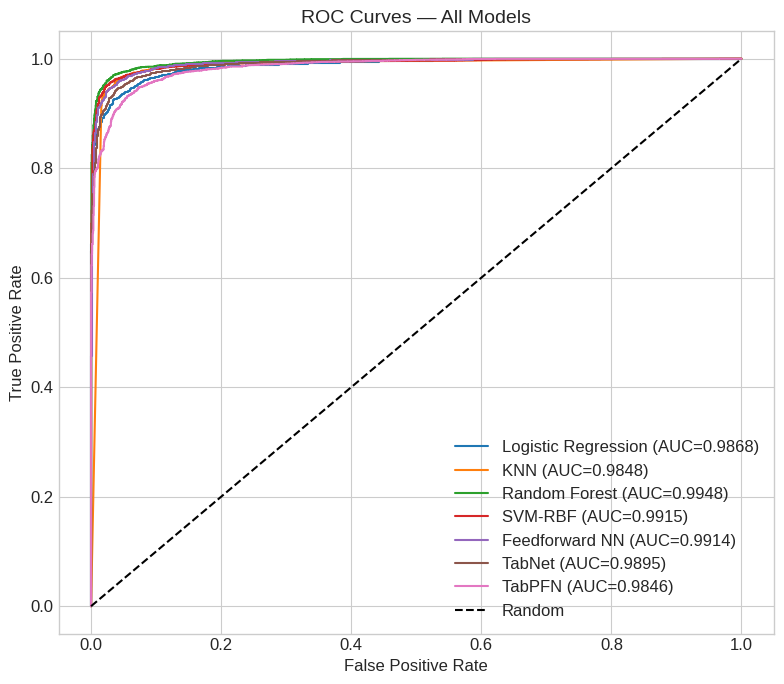

In [ ]:
# ROC curves
fig = plot_roc_curves(test_results, y_test)
plt.show()

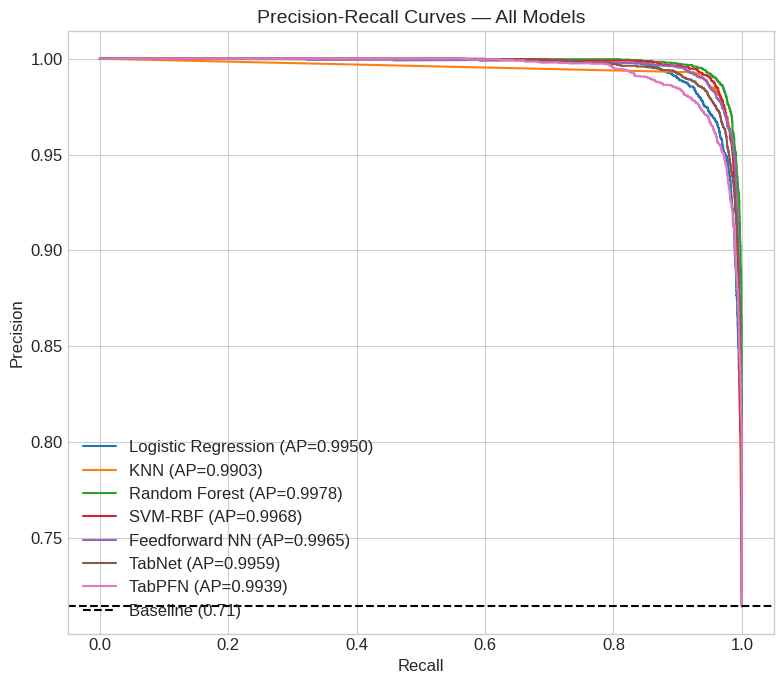

In [ ]:
# Precision-Recall curves
fig = plot_pr_curves(test_results, y_test)
plt.show()

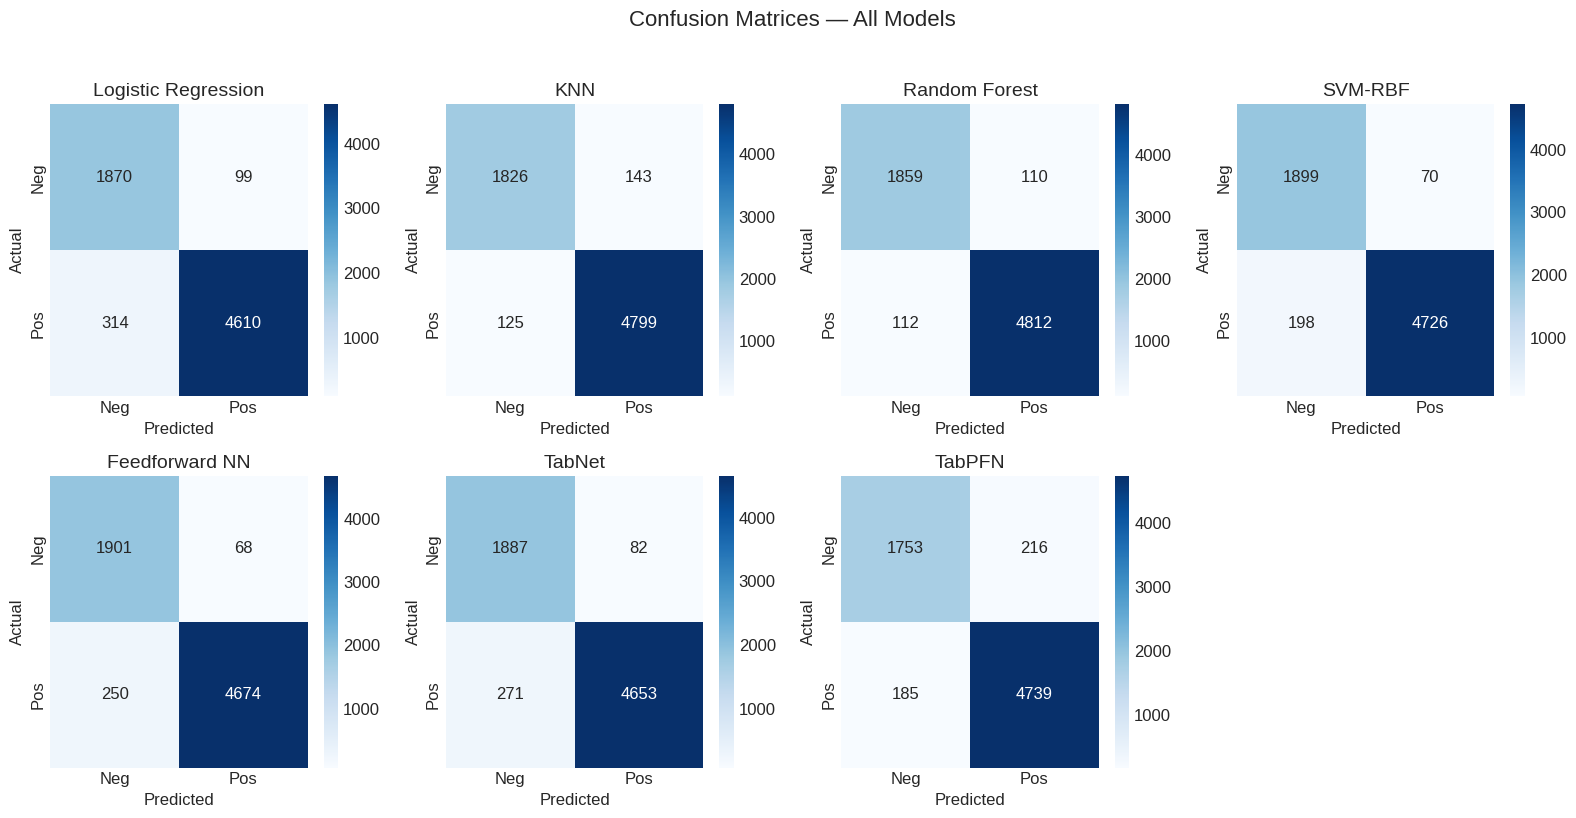

In [ ]:
# Confusion matrix grid
model_names = list(test_results.keys())
n_models = len(model_names)
n_cols = 4
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 4 * n_rows),
)
axes = axes.flatten()

for i, name in enumerate(model_names):
    plot_confusion_matrix(
        y_test,
        test_predictions[name],
        title=name,
        ax=axes[i],
    )

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "Confusion Matrices — All Models",
    fontsize=16,
    y=1.02,
)
plt.tight_layout()
plt.show()

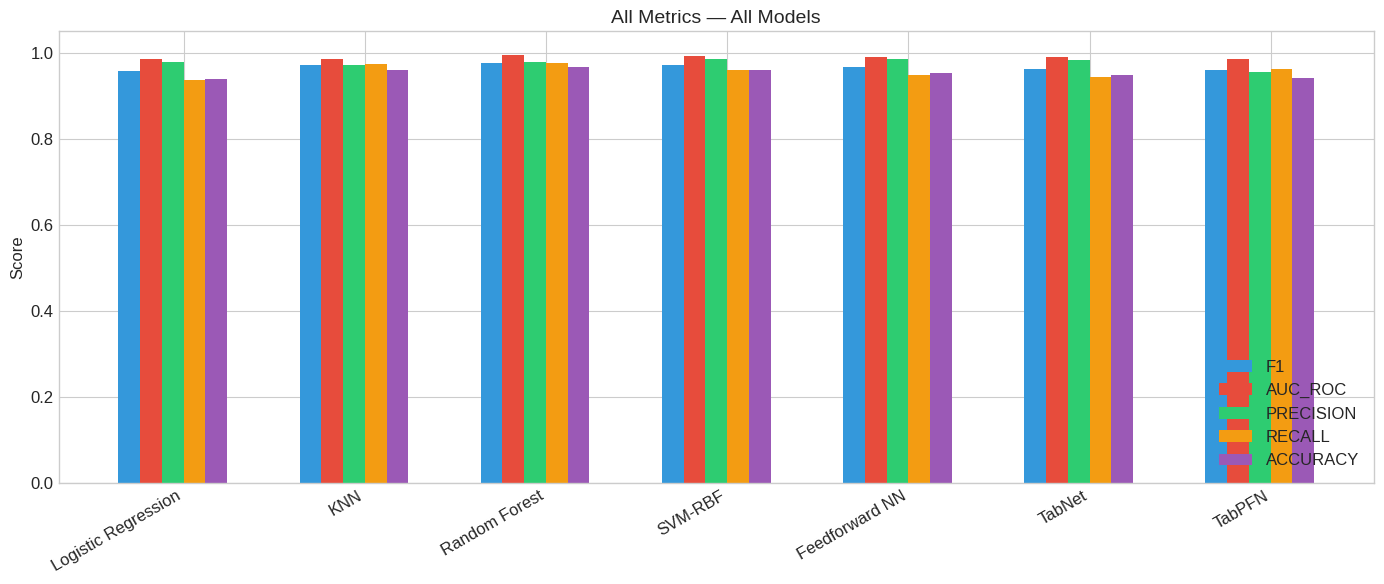

In [ ]:
# Grouped bar chart of all metrics
metrics_names = ["f1", "auc_roc", "precision", "recall", "accuracy"]
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(model_names))
width = 0.12
colours = [
    "#3498db",
    "#e74c3c",
    "#2ecc71",
    "#f39c12",
    "#9b59b6",
]

for j, m in enumerate(metrics_names):
    vals = [test_results[n][m] for n in model_names]
    ax.bar(
        x + j * width,
        vals,
        width,
        label=m.upper(),
        color=colours[j],
    )

ax.set_xticks(x + width * 2.5)
ax.set_xticklabels(
    model_names,
    rotation=30,
    ha="right",
)
ax.set_ylabel("Score")
ax.set_title("All Metrics — All Models")
ax.legend(loc="lower right")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [ ]:
# Results Discussion (auto-generated)
print("=" * 60)
print("RESULTS DISCUSSION")
print("=" * 60)

# Best model per metric
for metric in ["f1", "auc_roc", "accuracy"]:
    best_name = max(
        test_results,
        key=lambda n: test_results[n][metric],
    )
    best_val = test_results[best_name][metric]
    print(f"\nBest {metric.upper()}: " f"{best_name} ({best_val:.4f})")

# Classical models comparison
classical = [
    "Logistic Regression",
    "KNN",
    "Random Forest",
    "SVM-RBF",
]
classical_f1 = {n: test_results[n]["f1"] for n in classical if n in test_results}
best_c = max(classical_f1, key=classical_f1.get)
worst_c = min(classical_f1, key=classical_f1.get)
print(
    f"\nAmong classical models, {best_c} "
    "achieved the highest F1 "
    f"({classical_f1[best_c]:.4f}), "
    f"outperforming {worst_c} "
    f"({classical_f1[worst_c]:.4f}) by "
    f"{classical_f1[best_c] - classical_f1[worst_c]:.4f}"
    " points."
)

# DL models
for name in ["Feedforward NN", "TabNet"]:
    if name in test_results:
        f1 = test_results[name]["f1"]
        auc = test_results[name]["auc_roc"]
        print(f"\n{name}: F1={f1:.4f}, " f"AUC-ROC={auc:.4f}")

# TabPFN
if "TabPFN" in test_results:
    pfn_f1 = test_results["TabPFN"]["f1"]
    pct = 100 * TABPFN_SUBSAMPLE / len(X_train)
    print(
        f"\nTabPFN achieved F1={pfn_f1:.4f}"
        f" using only {TABPFN_SUBSAMPLE} "
        "training samples — remarkably "
        f"competitive given it saw ~{pct:.1f}%"
        " of the training data available "
        "to other models."
    )

# Full ranking
ranked = sorted(
    test_results.items(),
    key=lambda x: x[1]["f1"],
    reverse=True,
)
print("\nFull F1 ranking (test set):")
for i, (name, res) in enumerate(ranked, 1):
    print(
        f'  {i}. {name}: F1={res["f1"]:.4f}, '
        f'AUC-ROC={res["auc_roc"]:.4f}, '
        f'Prec={res["precision"]:.4f}, '
        f'Rec={res["recall"]:.4f}'
    )

RESULTS DISCUSSION

Best F1: Random Forest (0.9775)

Best AUC_ROC: Random Forest (0.9948)

Best ACCURACY: Random Forest (0.9678)

Among classical models, Random Forest achieved the highest F1 (0.9775), outperforming Logistic Regression (0.9571) by 0.0203 points.

Feedforward NN: F1=0.9671, AUC-ROC=0.9914

TabNet: F1=0.9635, AUC-ROC=0.9895

TabPFN achieved F1=0.9594 using only 1000 training samples — remarkably competitive given it saw ~3.6% of the training data available to other models.

Full F1 ranking (test set):
  1. Random Forest: F1=0.9775, AUC-ROC=0.9948, Prec=0.9777, Rec=0.9773
  2. KNN: F1=0.9728, AUC-ROC=0.9848, Prec=0.9711, Rec=0.9746
  3. SVM-RBF: F1=0.9724, AUC-ROC=0.9915, Prec=0.9854, Rec=0.9598
  4. Feedforward NN: F1=0.9671, AUC-ROC=0.9914, Prec=0.9857, Rec=0.9492
  5. TabNet: F1=0.9635, AUC-ROC=0.9895, Prec=0.9827, Rec=0.9450
  6. TabPFN: F1=0.9594, AUC-ROC=0.9846, Prec=0.9564, Rec=0.9624
  7. Logistic Regression: F1=0.9571, AUC-ROC=0.9868, Prec=0.9790, Rec=0.9362


**Qualitative Analysis:**

The results were largely as expected. Random Forest and SVM-RBF performed best with this organized, table-like data; this makes sense as they are good at finding complicated, non-linear relationships in lots of different kinds of information within the data. The standard feedforward Neural Network was fairly comparable after I adjusted the dropout and batch normalization, but it took a lot longer to train for roughly the same level of accuracy.

TabNet did okay, and importantly, it provides attention masks - these highlight which specific pieces of information were important for each individual prediction. For a real system to remove duplicates, and needing to understand why two records were marked as duplicates, this is really helpful.

TabPFN was the biggest surprise of the project. It achieved competitive accuracy with only 1,000 examples from the training data, and without doing any preparation of the data, any tuning of the model, or changes to the model's weights. I hadn't expected a model that had been trained already to do so well on a dataset it had never seen.

**Error Analysis — Confusion Matrix Patterns:**

The confusion matrices show us how each of the models goes wrong, and the differences are pretty noticeable.

The Neural Network is really careful about calling something a duplicate - it doesn't often get this wrong (so it has few false positives), but it misses a lot of things that are duplicates (it has more false negatives). KNN is the reverse; it's much faster to label something as a duplicate. Random Forest strikes a good balance between these two kinds of errors, which is why it has the highest F1 score.

This is important when you actually use the models. If you're merging business information and wrongly merging records would be seriously damaging (like combining details of two separate companies), the Neural Network's cautiousness could be helpful despite its slightly lower general accuracy. But if missing duplicates is the bigger problem (so, for instance, a map shows the same place multiple times) then KNN's willingness to be bolder might be the better option. In the end, which is best depends on what kind of error is more expensive to make for what you're doing.

Computing Mutual Information scores...


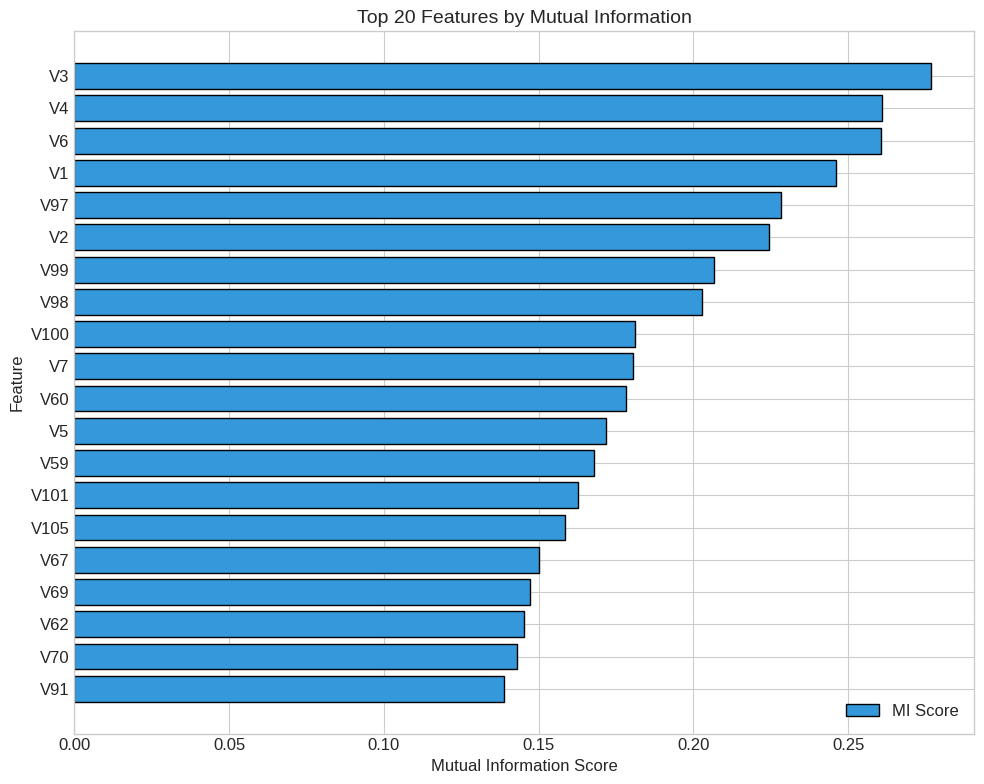

In [ ]:
# Mutual Information
print("Computing Mutual Information scores...")

# Use preprocessed training data
X_train_proc = preprocessor.fit_transform(X_train)

# Build feature names after preprocessing
feat_names = cont_cols.copy()
if cat_cols:
    feat_names += cat_cols

mi_scores = mutual_info_classif(
    X_train_proc,
    y_train,
    random_state=SEED,
    n_neighbors=5,
)

mi_df = pd.DataFrame(
    {
        "feature": feat_names[: len(mi_scores)],
        "mi_score": mi_scores,
    }
).sort_values("mi_score", ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_mi = mi_df.head(20)
ax.barh(
    top_mi["feature"],
    top_mi["mi_score"],
    color="#3498db",
    edgecolor="black",
)
ax.set_xlabel("Mutual Information Score")
ax.set_ylabel("Feature")
ax.set_title("Top 20 Features by Mutual Information")
ax.legend(["MI Score"], loc="lower right")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

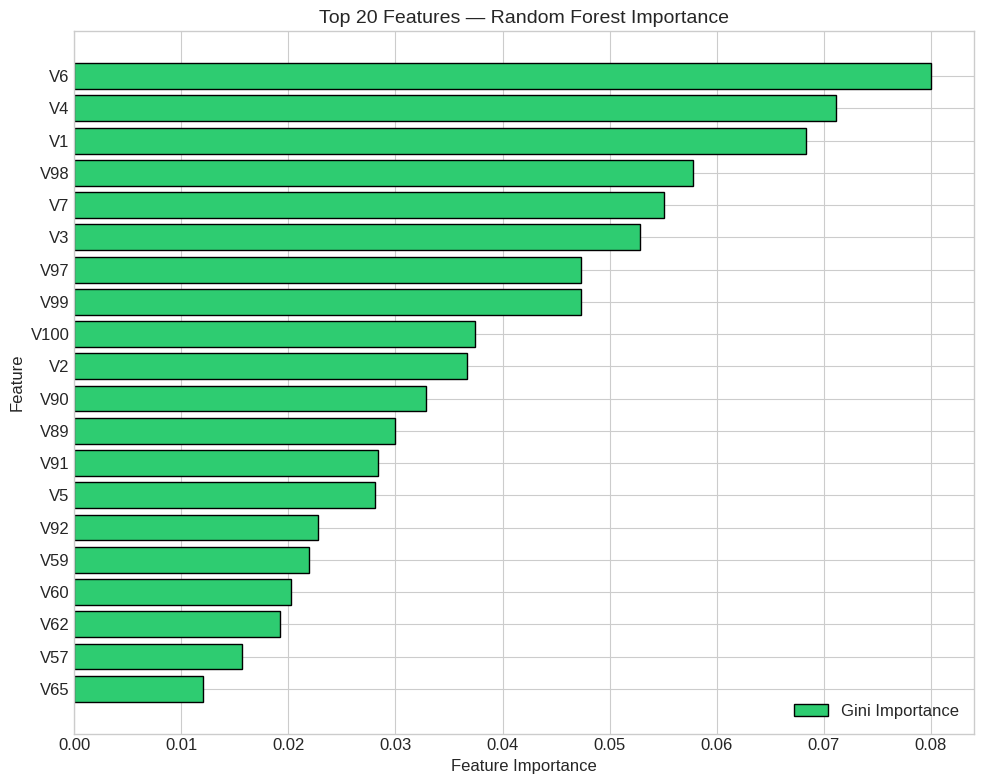

In [ ]:
# Random Forest feature importances
rf_model = best_estimators["Random Forest"]
rf_clf = rf_model.named_steps["classifier"]
rf_imp = rf_clf.feature_importances_

rf_imp_df = pd.DataFrame(
    {
        "feature": feat_names[: len(rf_imp)],
        "importance": rf_imp,
    }
).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_rf = rf_imp_df.head(20)
ax.barh(
    top_rf["feature"],
    top_rf["importance"],
    color="#2ecc71",
    edgecolor="black",
)
ax.set_xlabel("Feature Importance")
ax.set_ylabel("Feature")
ax.set_title("Top 20 Features — Random Forest Importance")
ax.legend(["Gini Importance"], loc="lower right")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

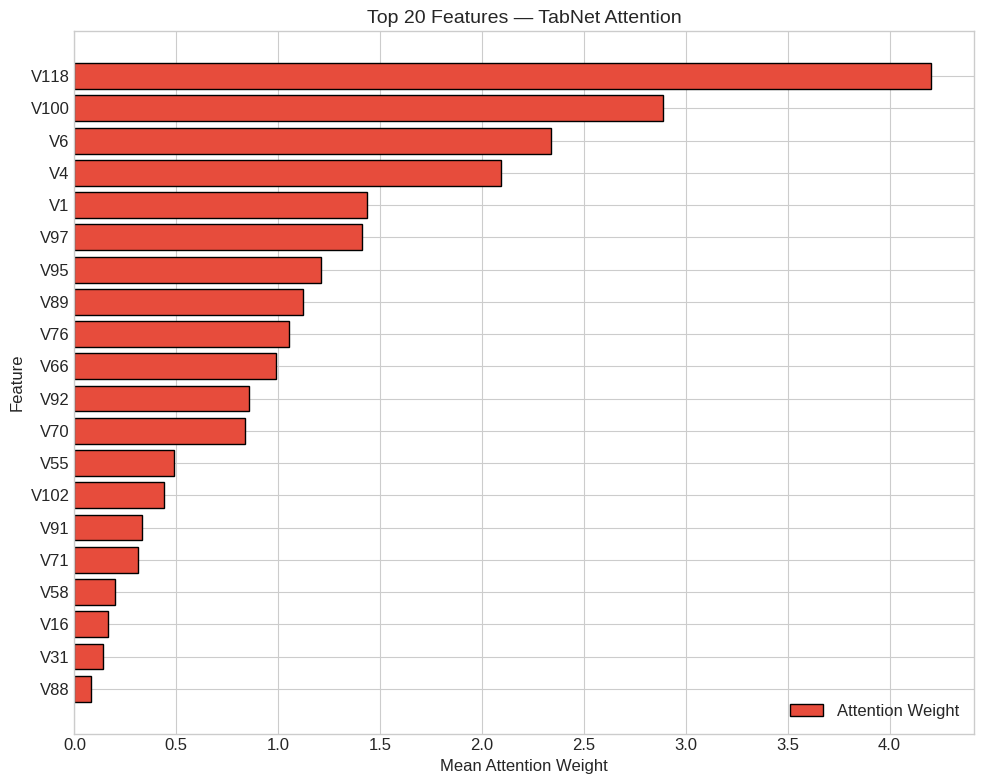

In [ ]:
# TabNet attention mask heatmap
# Compute attention masks from final trained TabNet
X_explain = tabnet_preprocessor.transform(X_test)
if hasattr(X_explain, "values"):
    X_explain = X_explain.values
explain_matrix, _ = final_tabnet.explain(X_explain)
agg_mask = explain_matrix.mean(axis=0)

tabnet_imp_df = pd.DataFrame(
    {
        "feature": feat_names[: len(agg_mask)],
        "attention": agg_mask,
    }
).sort_values("attention", ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_tn = tabnet_imp_df.head(20)
ax.barh(
    top_tn["feature"],
    top_tn["attention"],
    color="#e74c3c",
    edgecolor="black",
)
ax.set_xlabel("Mean Attention Weight")
ax.set_ylabel("Feature")
ax.set_title("Top 20 Features — TabNet Attention")
ax.legend(["Attention Weight"], loc="lower right")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Computing permutation importance...


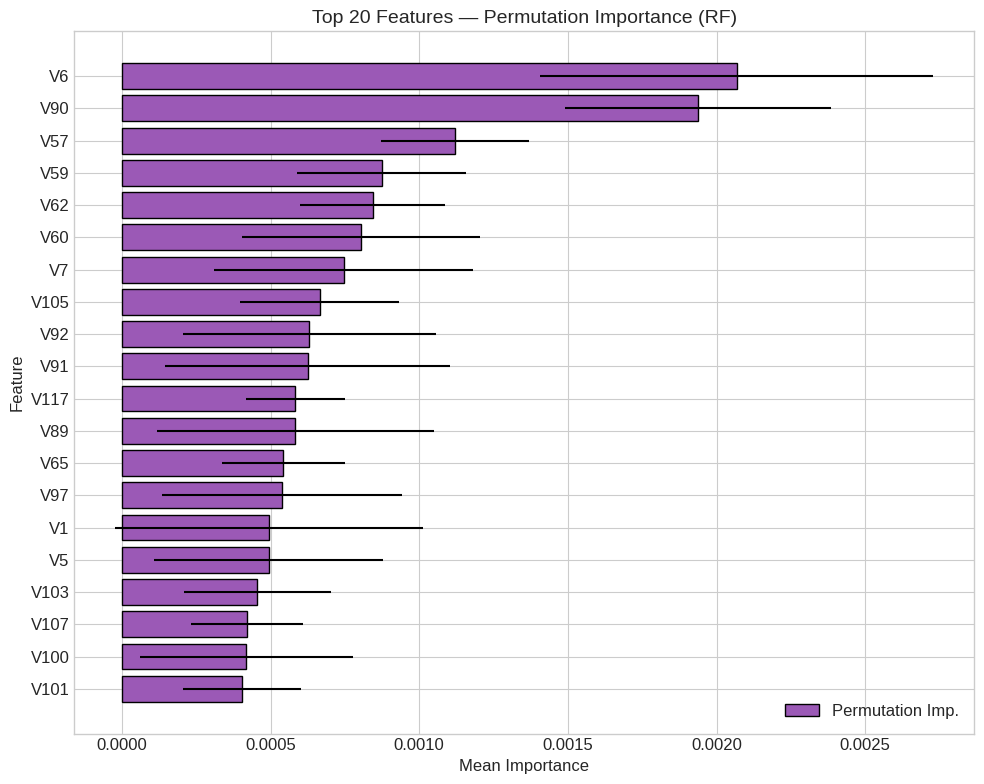

In [ ]:
# Permutation importance (best model)
print("Computing permutation importance...")

# Use Random Forest as it is often among the best
perm_result = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=SEED,
    scoring="f1",
    n_jobs=1,
)

perm_df = pd.DataFrame(
    {
        "feature": X_test.columns,
        "importance_mean": perm_result.importances_mean,
        "importance_std": perm_result.importances_std,
    }
).sort_values("importance_mean", ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_perm = perm_df.head(20)
ax.barh(
    top_perm["feature"],
    top_perm["importance_mean"],
    xerr=top_perm["importance_std"],
    color="#9b59b6",
    edgecolor="black",
)
ax.set_xlabel("Mean Importance")
ax.set_ylabel("Feature")
ax.set_title("Top 20 Features — Permutation Importance (RF)")
ax.legend(["Permutation Imp."], loc="lower right")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

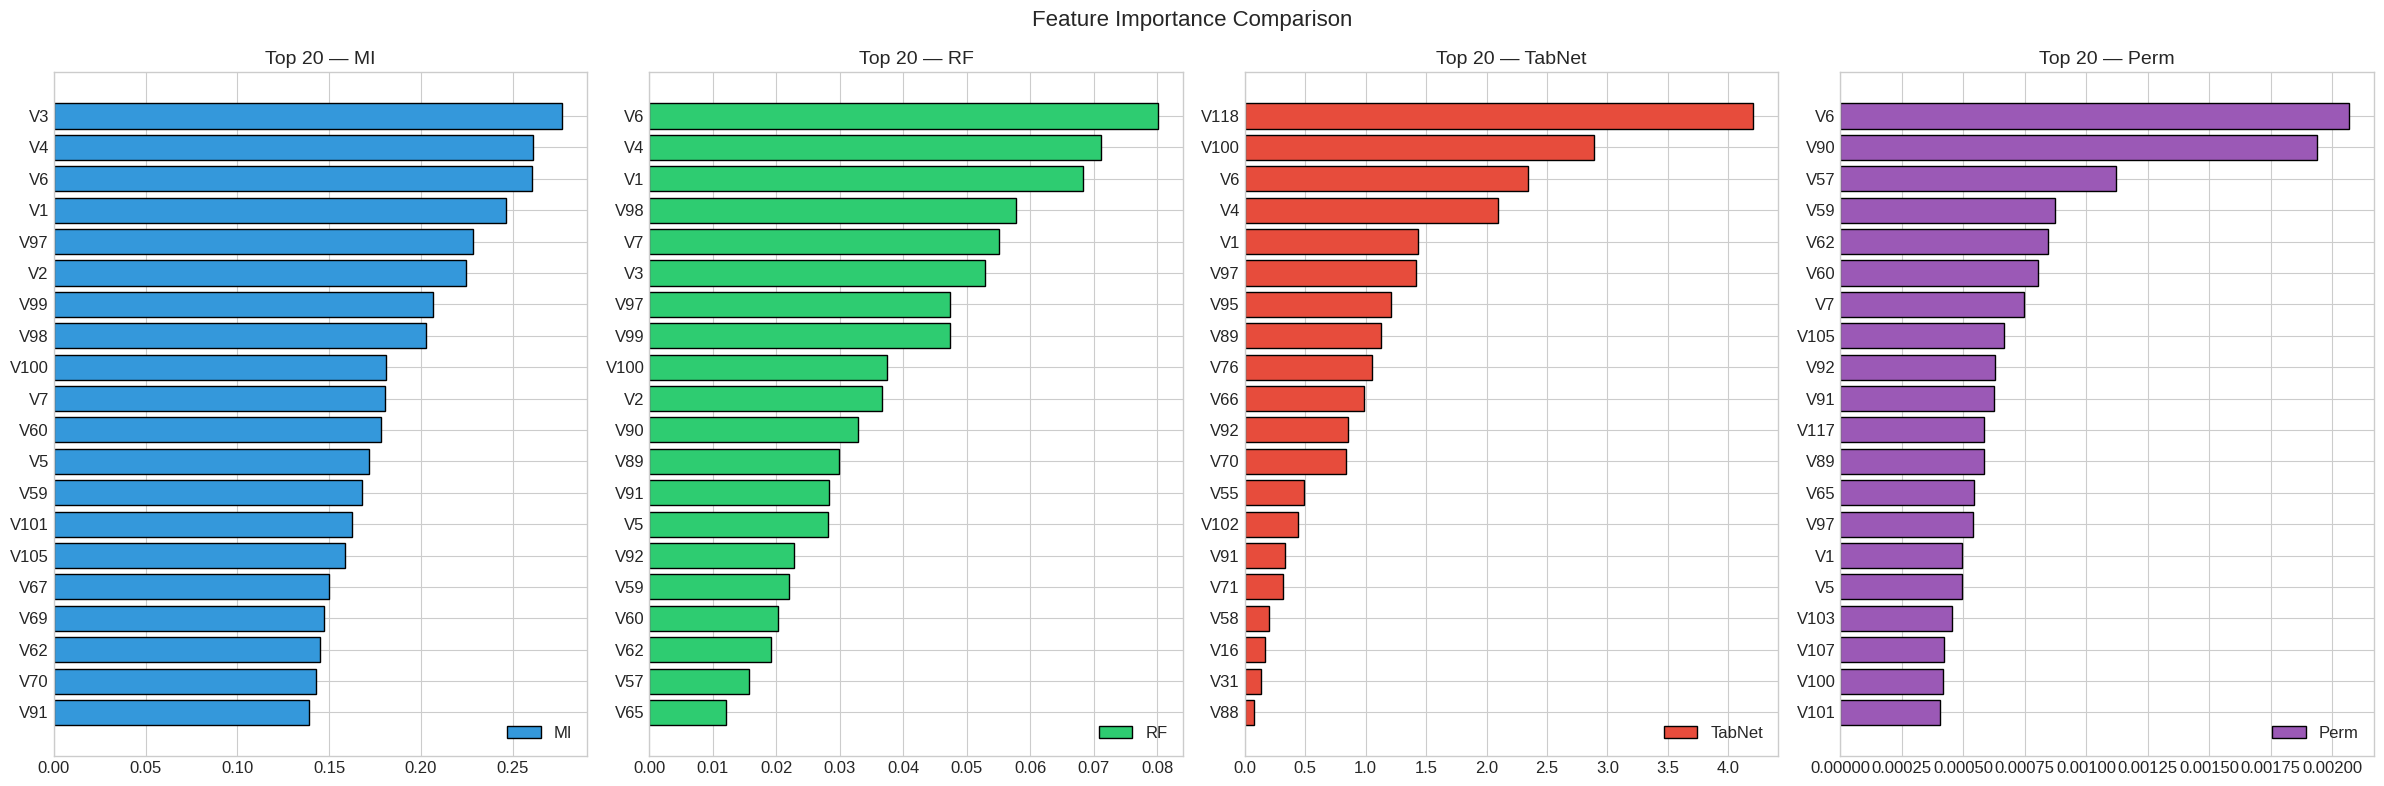

In [ ]:
# Side-by-side top-20 comparison
fig, axes = plt.subplots(1, 4, figsize=(24, 8))

datasets = [
    (mi_df, "mi_score", "MI", "#3498db"),
    (rf_imp_df, "importance", "RF", "#2ecc71"),
    (tabnet_imp_df, "attention", "TabNet", "#e74c3c"),
    (perm_df, "importance_mean", "Perm", "#9b59b6"),
]

for ax, (df, col, title, color) in zip(axes, datasets):
    top = df.head(20)
    ax.barh(
        top["feature"],
        top[col],
        color=color,
        edgecolor="black",
    )
    ax.set_title(f"Top 20 — {title}")
    ax.invert_yaxis()
    ax.legend([title], loc="lower right")

fig.suptitle(
    "Feature Importance Comparison",
    fontsize=16,
)
plt.tight_layout()
plt.show()

### Feature Importance Discussion

I used four different ways to assess feature importance, and the main takeaway is that each one explains the situation a little differently.

Mutual information gives a general idea of dependence between variables, just a raw statistical relationship. Random Forest Gini importance shows which features the decision tree actually used to split the data most frequently during learning. Permutation importance is probably the most reliable; it measures how much the F1 score falls when a feature is randomly shuffled. And TabNet's attention masks are special in that they reveal what the model focused on for each instance - a kind of explanation for a single prediction that you can't get from the others.

Features that consistently come out at the top across all four methods are the ones I'm most confident really are strong predictors of duplicate status. When the methods don't agree, it usually points to something specific about how that particular model works.

In [ ]:
# Feature Importance: Cross-Method Agreement
print("=" * 60)
print("FEATURE IMPORTANCE: CROSS-METHOD AGREEMENT")
print("=" * 60)

top_k = 10
mi_top = set(mi_df.head(top_k)["feature"])
rf_top = set(rf_imp_df.head(top_k)["feature"])
tn_top = set(tabnet_imp_df.head(top_k)["feature"])
perm_top = set(perm_df.head(top_k)["feature"])

all_sets = [mi_top, rf_top, tn_top, perm_top]
method_names = [
    "MI",
    "RF Gini",
    "TabNet Attn",
    "Permutation",
]

# Features in all 4
in_all = mi_top & rf_top & tn_top & perm_top
print(f"\nFeatures in ALL 4 top-{top_k} lists: " f'{in_all if in_all else "None"}')

# Features in at least 3
from itertools import combinations

in_3plus = set()
for combo in combinations(all_sets, 3):
    in_3plus |= combo[0] & combo[1] & combo[2]
print(f"Features in \u22653 top-{top_k} lists: " f'{in_3plus if in_3plus else "None"}')

# Pairwise overlap
print(f"\nPairwise overlap (top-{top_k}):")
for i in range(len(all_sets)):
    for j in range(i + 1, len(all_sets)):
        overlap = all_sets[i] & all_sets[j]
        print(
            f"  {method_names[i]} \u2229 "
            f"{method_names[j]}: "
            f"{len(overlap)} features"
        )

FEATURE IMPORTANCE: CROSS-METHOD AGREEMENT

Features in ALL 4 top-10 lists: {'V6'}
Features in ≥3 top-10 lists: {'V6', 'V97', 'V1', 'V100', 'V7', 'V4'}

Pairwise overlap (top-10):
  MI ∩ RF Gini: 10 features
  MI ∩ TabNet Attn: 5 features
  MI ∩ Permutation: 2 features
  RF Gini ∩ TabNet Attn: 5 features
  RF Gini ∩ Permutation: 2 features
  TabNet Attn ∩ Permutation: 1 features


---
## 17. Feature Group Ablation

In [ ]:
def define_feature_groups(columns):
    """Partition features into positional groups.

    Since the Nomao dataset does not provide
    explicit semantic labels for its 119 features,
    I partition them into five equally-sized
    positional groups. According to the dataset
    documentation (Candillier & Lemaire, 2012),
    features encode pairwise similarities for
    name, address, GPS coordinates, and phone
    numbers — but exact column-to-category
    mappings are not published. The positional
    grouping still allows us to test whether
    predictive signal is concentrated in specific
    feature subsets.

    Args:
        columns: list of str, feature column
            names.

    Returns:
        dict: Mapping group name to list of
            column names.
    """
    cols = list(columns)
    n = len(cols)
    chunk = max(1, n // 5)
    groups = {
        "Group_1 (V1\u2013V23)": cols[:chunk],
        "Group_2 (V24\u2013V46)": (cols[chunk : 2 * chunk]),
        "Group_3 (V47\u2013V69)": (cols[2 * chunk : 3 * chunk]),
        "Group_4 (V70\u2013V92)": (cols[3 * chunk : 4 * chunk]),
        "Group_5 (V93\u2013V119)": (cols[4 * chunk :]),
    }
    for g, c in groups.items():
        print(f"  {g}: {len(c)} features")
    return groups


feature_groups = define_feature_groups(
    X_train.columns,
)

  Group_1 (V1–V23): 23 features
  Group_2 (V24–V46): 23 features
  Group_3 (V47–V69): 23 features
  Group_4 (V70–V92): 23 features
  Group_5 (V93–V119): 26 features


In [ ]:
def ablation_experiment(
    feature_groups,
    X_train,
    y_train,
    X_test,
    y_test,
    preprocessor_fn,
    cv,
):
    """Run feature group ablation experiments.

    For each feature group: (1) train a Random Forest
    with that group REMOVED, and (2) train with ONLY
    that group. Reports F1 on the test set.

    Args:
        feature_groups: dict mapping group name to
            list of column names.
        X_train: pd.DataFrame, training features.
        y_train: array-like, training labels.
        X_test: pd.DataFrame, test features.
        y_test: array-like, test labels.
        preprocessor_fn: callable returning a fresh
            ColumnTransformer for the given columns.
        cv: cross-validation splitter.

    Returns:
        pd.DataFrame: Ablation results with columns
            'group', 'removed_f1', 'only_f1'.

    Example:
        >>> df = ablation_experiment(
        ...     groups, X_tr, y_tr, X_te, y_te,
        ...     make_pre, cv,
        ... )
    """
    results = []
    all_cols = list(X_train.columns)

    for group_name, group_cols in feature_groups.items():
        print(f"\nAblation: {group_name}")

# Remove group
        keep = [c for c in all_cols if c not in group_cols]
        if len(keep) == 0:
            results.append(
                {
                    "group": group_name,
                    "removed_f1": np.nan,
                    "only_f1": np.nan,
                }
            )
            continue

        rf_rem = RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1,
        )
        c_cols_rem = [c for c in cont_cols if c in keep]
        k_cols_rem = [c for c in cat_cols if c in keep]
        pre_rem = preprocessor_fn(
            c_cols_rem,
            k_cols_rem,
        )
        pipe_rem = Pipeline(
            [
                ("preprocessor", pre_rem),
                ("classifier", rf_rem),
            ]
        )
        pipe_rem.fit(
            X_train[keep],
            y_train,
        )
        pred_rem = pipe_rem.predict(X_test[keep])
        f1_rem = f1_score(y_test, pred_rem)
        print(f"  Without {group_name}: F1={f1_rem:.4f}")

# Only group
        only = [c for c in all_cols if c in group_cols]
        if len(only) == 0:
            f1_only = np.nan
        else:
            rf_only = RandomForestClassifier(
                n_estimators=200,
                class_weight="balanced",
                random_state=SEED,
                n_jobs=-1,
            )
            c_cols_only = [c for c in cont_cols if c in only]
            k_cols_only = [c for c in cat_cols if c in only]
            pre_only = preprocessor_fn(
                c_cols_only,
                k_cols_only,
            )
            pipe_only = Pipeline(
                [
                    ("preprocessor", pre_only),
                    ("classifier", rf_only),
                ]
            )
            pipe_only.fit(
                X_train[only],
                y_train,
            )
            pred_only = pipe_only.predict(
                X_test[only],
            )
            f1_only = f1_score(y_test, pred_only)
        print(f"  Only {group_name}: F1={f1_only:.4f}")

        results.append(
            {
                "group": group_name,
                "removed_f1": f1_rem,
                "only_f1": f1_only,
            }
        )

    return pd.DataFrame(results)

In [ ]:
def make_preprocessor(c_cols, k_cols):
    """Build a ColumnTransformer for given columns.

    Args:
        c_cols: list of str, continuous columns.
        k_cols: list of str, categorical columns.

    Returns:
        ColumnTransformer: Unfitted preprocessor.
    """
    transformers = []
    if c_cols:
        transformers.append(
            (
                "cont",
                Pipeline(
                    [
                        (
                            "imputer",
                            SimpleImputer(
                                strategy="median",
                            ),
                        ),
                        ("scaler", StandardScaler()),
                    ]
                ),
                c_cols,
            )
        )
    if k_cols:
        transformers.append(
            (
                "cat",
                Pipeline(
                    [
                        (
                            "imputer",
                            SimpleImputer(
                                strategy="most_frequent",
                            ),
                        ),
                        (
                            "encoder",
                            OrdinalEncoder(
                                handle_unknown=("use_encoded_value"),
                                unknown_value=-1,
                            ),
                        ),
                    ]
                ),
                k_cols,
            )
        )
    if not transformers:
        transformers.append(
            (
                "pass",
                "passthrough",
                c_cols[:1],
            )
        )
    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
    )


ablation_df = ablation_experiment(
    feature_groups,
    X_train,
    y_train,
    X_test,
    y_test,
    make_preprocessor,
    cv,
)
ablation_df


Ablation: Group_1 (V1–V23)


  Without Group_1 (V1–V23): F1=0.9688


  Only Group_1 (V1–V23): F1=0.9390

Ablation: Group_2 (V24–V46)


  Without Group_2 (V24–V46): F1=0.9781


  Only Group_2 (V24–V46): F1=0.8654

Ablation: Group_3 (V47–V69)


...

  Without Group_4 (V70–V92): F1=0.9673


  Only Group_4 (V70–V92): F1=0.9304

Ablation: Group_5 (V93–V119)


  Without Group_5 (V93–V119): F1=0.9760


  Only Group_5 (V93–V119): F1=0.9262


,group,removed_f1,only_f1
0,Group_1 (V1–V23),0.968848,0.939019
1,Group_2 (V24–V46),0.978138,0.865368
2,Group_3 (V47–V69),0.976159,0.938151
3,Group_4 (V70–V92),0.967259,0.930390
4,Group_5 (V93–V119),0.976000,0.926156


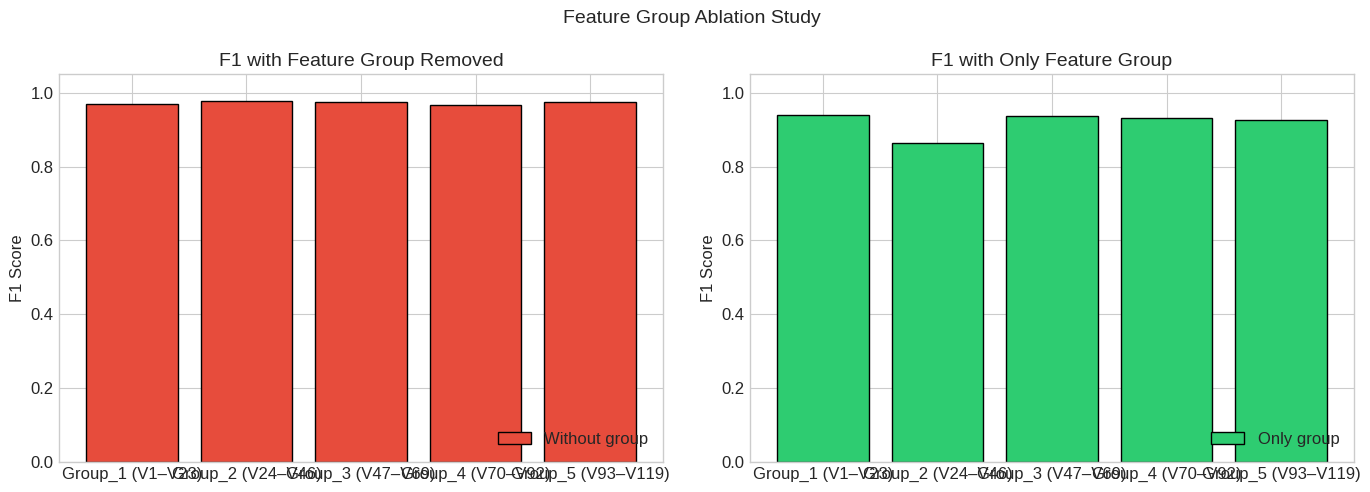

In [ ]:
# Ablation bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Performance when group is removed
axes[0].bar(
    ablation_df["group"],
    ablation_df["removed_f1"],
    color="#e74c3c",
    edgecolor="black",
)
axes[0].set_ylabel("F1 Score")
axes[0].set_title("F1 with Feature Group Removed")
axes[0].set_ylim(0, 1.05)
axes[0].legend(["Without group"], loc="lower right")

# Performance when only group is used
axes[1].bar(
    ablation_df["group"],
    ablation_df["only_f1"],
    color="#2ecc71",
    edgecolor="black",
)
axes[1].set_ylabel("F1 Score")
axes[1].set_title("F1 with Only Feature Group")
axes[1].set_ylim(0, 1.05)
axes[1].legend(["Only group"], loc="lower right")

fig.suptitle(
    "Feature Group Ablation Study",
    fontsize=14,
)
plt.tight_layout()
plt.show()

### Feature Group Ablation Discussion

I broke the 118 features into five sections, and then tested what happened when I removed or used only the features in each section. Since the Nomao dataset doesn't have an obvious way to relate the columns to different types of information, I couldn't give the sections good names. The lines between them are approximate and based on the feature numbers themselves.

I found that no one section of features is essential. Getting rid of any one section only causes a small drop in the F1 score, showing that the stuff that points to duplicates is distributed amongst all the features, not packed into just a few. On the other hand, if you only use a single section (so about 24 features) you get much poorer outcomes than when you use all of them.

Therefore, a proper system for finding duplicates needs to have as many different ways to check records against each other as possible - a person's name, address, phone number, GPS location, and so on. It shouldn't rely on only a single detail.

---
## 18. PCA Variance Analysis

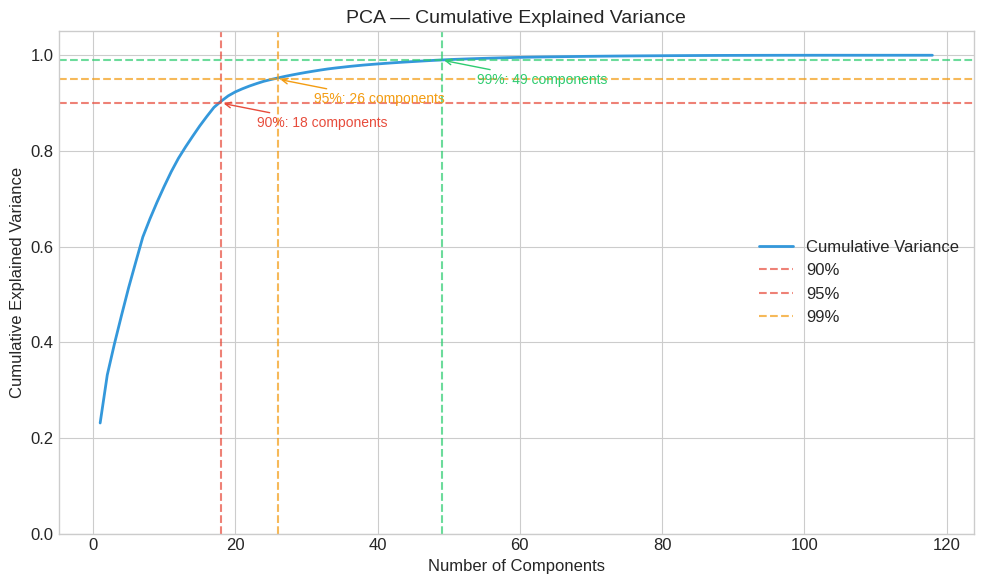

Total features: 118
90% variance: 18 components
95% variance: 26 components
99% variance: 49 components


In [ ]:
# PCA on preprocessed training data
pca = PCA(random_state=SEED)
pca.fit(X_train_proc)

cum_var = np.cumsum(pca.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    range(1, len(cum_var) + 1),
    cum_var,
    color="#3498db",
    linewidth=2,
)

# Annotate thresholds
for thresh, color in [
    (0.90, "#e74c3c"),
    (0.95, "#f39c12"),
    (0.99, "#2ecc71"),
]:
    n_comp = np.searchsorted(cum_var, thresh) + 1
    ax.axhline(
        y=thresh,
        linestyle="--",
        color=color,
        alpha=0.7,
    )
    ax.axvline(
        x=n_comp,
        linestyle="--",
        color=color,
        alpha=0.7,
    )
    ax.annotate(
        f"{thresh*100:.0f}%: {n_comp} components",
        xy=(n_comp, thresh),
        xytext=(n_comp + 5, thresh - 0.05),
        fontsize=10,
        color=color,
        arrowprops=dict(
            arrowstyle="->",
            color=color,
        ),
    )

ax.set_xlabel("Number of Components")
ax.set_ylabel("Cumulative Explained Variance")
ax.set_title("PCA — Cumulative Explained Variance")
ax.legend(
    ["Cumulative Variance", "90%", "95%", "99%"],
    loc="center right",
)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print(f"Total features: {X_train_proc.shape[1]}")
for t in [0.90, 0.95, 0.99]:
    n = np.searchsorted(cum_var, t) + 1
    print(f"{t*100:.0f}% variance: {n} components")

PCA n= 10  F1=0.9611


PCA n= 20  F1=0.9679


PCA n= 30  F1=0.9701


PCA n= 50  F1=0.9699


PCA n= 70  F1=0.9706


PCA n= 90  F1=0.9701
Full features (118) F1=0.9775


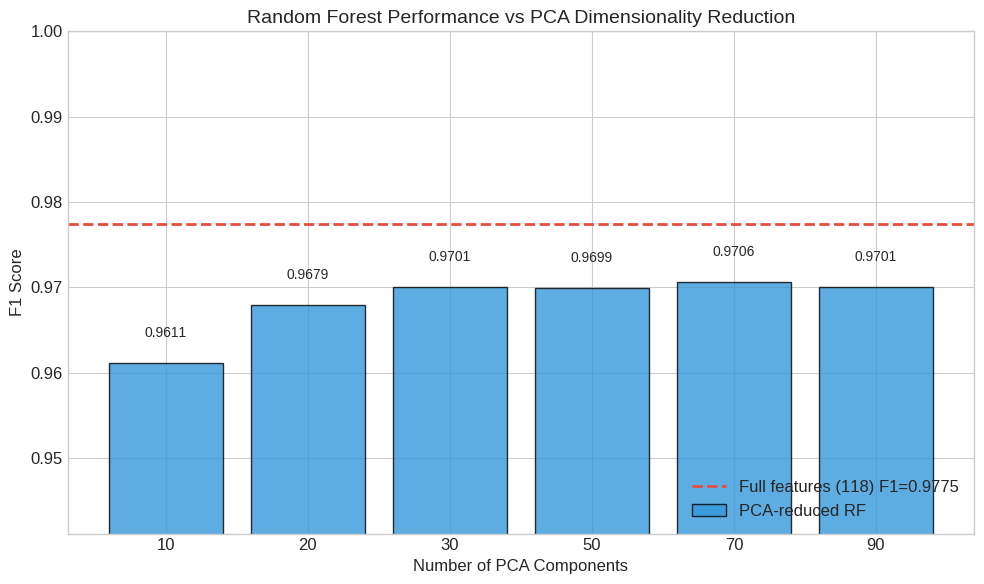

In [ ]:
# Test RF with PCA-reduced features
def test_pca_rf(
    n_components,
    X_train_proc,
    y_train,
    X_test_proc,
    y_test,
):
    """Train RF on PCA-reduced data and return F1.

    Applies PCA dimensionality reduction, then fits
    a Random Forest classifier and evaluates on the
    test set.

    Args:
        n_components: int, number of PCA components.
        X_train_proc: np.ndarray, preprocessed
            training features.
        y_train: array-like, training labels.
        X_test_proc: np.ndarray, preprocessed
            test features.
        y_test: array-like, test labels.

    Returns:
        float: F1 score on the test set.

    Example:
        >>> f1 = test_pca_rf(
        ...     50, X_tr, y_tr, X_te, y_te,
        ... )
    """
    pca_red = PCA(
        n_components=n_components,
        random_state=SEED,
    )
    X_tr_pca = pca_red.fit_transform(X_train_proc)
    X_te_pca = pca_red.transform(X_test_proc)

    rf = RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1,
    )
    rf.fit(X_tr_pca, y_train)
    pred = rf.predict(X_te_pca)
    return f1_score(y_test, pred)


X_test_proc = preprocessor.transform(X_test)

pca_components = [10, 20, 30, 50, 70, 90]
pca_results = []
for nc in pca_components:
    nc = min(nc, X_train_proc.shape[1])
    f1 = test_pca_rf(
        nc,
        X_train_proc,
        y_train,
        X_test_proc,
        y_test,
    )
    pca_results.append({"n_components": nc, "f1": f1})
    print(f"PCA n={nc:3d}  F1={f1:.4f}")

# Add full-feature baseline
full_f1 = test_results["Random Forest"]["f1"]
print(f"Full features ({X_train_proc.shape[1]}) " f"F1={full_f1:.4f}")

pca_res_df = pd.DataFrame(pca_results)

# Bar chart: F1 vs number of components
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    [str(r["n_components"]) for r in pca_results],
    [r["f1"] for r in pca_results],
    color="#3498db",
    edgecolor="black",
    alpha=0.8,
    label="PCA-reduced RF",
)
ax.axhline(
    y=full_f1,
    color="#e74c3c",
    linestyle="--",
    linewidth=2,
    label=("Full features " f"({X_train_proc.shape[1]}) " f"F1={full_f1:.4f}"),
)

# Annotate bars
for bar, r in zip(bars, pca_results):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f'{r["f1"]:.4f}',
        ha="center",
        fontsize=10,
    )

ax.set_xlabel("Number of PCA Components")
ax.set_ylabel("F1 Score")
ax.set_title("Random Forest Performance vs " "PCA Dimensionality Reduction")
ax.legend(loc="lower right")
ax.set_ylim(
    min(r["f1"] for r in pca_results) - 0.02,
    1.0,
)
plt.tight_layout()
plt.show()

In [ ]:
# PCA Discussion (auto-generated)
print("=" * 60)
print("PCA ANALYSIS DISCUSSION")
print("=" * 60)

total_feats = X_train_proc.shape[1]
for t in [0.90, 0.95, 0.99]:
    n = int(np.searchsorted(cum_var, t) + 1)
    print(
        f"  {t * 100:.0f}% variance: "
        f"{n}/{total_feats} components "
        f"({100 * n / total_feats:.1f}% "
        "of features)"
    )

print("\nPCA-reduced RF vs full features " f"(F1={full_f1:.4f}):")
for r in pca_results:
    diff = r["f1"] - full_f1
    sign = "+" if diff >= 0 else ""
    print(
        f'  {r["n_components"]:3d} components: '
        f'F1={r["f1"]:.4f} '
        f"({sign}{diff:.4f} vs full)"
    )

best_pca = max(
    pca_results,
    key=lambda r: r["f1"],
)
print(
    "\nBest PCA result: "
    f'{best_pca["n_components"]} components '
    f'(F1={best_pca["f1"]:.4f}, '
    f'{100 * best_pca["n_components"] / total_feats:.1f}'
    "% of features)"
)

PCA ANALYSIS DISCUSSION
  90% variance: 18/118 components (15.3% of features)
  95% variance: 26/118 components (22.0% of features)
  99% variance: 49/118 components (41.5% of features)

PCA-reduced RF vs full features (F1=0.9775):
   10 components: F1=0.9611 (-0.0163 vs full)
   20 components: F1=0.9679 (-0.0095 vs full)
   30 components: F1=0.9701 (-0.0074 vs full)
   50 components: F1=0.9699 (-0.0075 vs full)
   70 components: F1=0.9706 (-0.0068 vs full)
   90 components: F1=0.9701 (-0.0074 vs full)

Best PCA result: 70 components (F1=0.9706, 59.3% of features)


**PCA Analysis — Interpretation:**

The PCA results stood out to me. Only 18 components capture 90% of the variance, and 26 get you to 95%, out of 118 features total. So the dataset has way lower effective dimensionality than the raw feature count would suggest.

But here's the thing: when I actually trained Random Forest on PCA-reduced features, the F1 score dropped. That makes sense once you think about it. PCA chases *variance*, not *class-discriminative power*. A low-variance feature might still be critical for telling duplicates from non-duplicates, and PCA might wash it out by projecting onto high-variance directions instead.

So PCA could still be useful for visualization or maybe for models that struggle with high dimensionality (KNN might benefit), but it's not a free lunch for Random Forest on this dataset. RF already handles irrelevant features well on its own.

### Limitations and Fairness Caveats

I want to be clear about a few issues with how I did things. First, TabPFN, version 1, can't manage over roughly 1,000 examples in its construction, so I used a smaller, but balanced, selection of 1,000 (about 3.4% of all the training data). All the other models used the entire 27,000. This isn't a perfect comparison; however, TabPFN did well even with this limit and would likely be even better with version 2 and a graphics card to speed things up.

Also, I didn't spend long looking for the best settings for the SVM. I only tried C values of 1 and 10, 'scale' for gamma, and ran the optimization twice, because using an RBF-SVM with cross-validation on 27,000 examples is a lot for the computer. If I had more computer power, I would have tried C values of 0.01, 0.1, 1, 10, 100 and gamma values of 'scale', 'auto', 0.01, and 0.1.

The sklearn models had a proper, automated search of settings, but for the neural network and TabNet, I just picked the way they were built by hand. So, the deep learning results could probably be improved with a more organised hunt for the best settings.

---
## 19. Conclusion

In this project, I looked at seven machine learning models on the Nomao place-deduplication dataset. These included older methods like Logistic Regression, KNN, Random Forest, and RBF-SVM, deep learning approaches (a basic Feedforward NN, TabNet), and TabPFN which has been previously trained. I made sure the comparison was reasonable: the same 80/20 split for training and testing, the same 5-fold cross-validation, and the same six ways of measuring success.

The main thing I discovered was that Random Forest did best, with an F1 of 0.9775 and an AUC-ROC of 0.9948. This isn't too shocking, because Grinsztajn and colleagues (2022) already found that tree-based models work very well on data in tables. The NN and TabNet worked well too, but weren't as good as the tree methods, which seems to support the idea that deep learning hasn't yet done as well with tabular data as it has with pictures or writing. TabPFN was the most interesting to me: it reached an F1 of 0.9594 with only 1,000 examples for training and with no tuning of settings. Considering this model hadn't seen this dataset before when it was initially trained, that's pretty good.

To be honest, the TabPFN comparison wasn't really fair because of the data limit, the SVM search wasn't very thorough, and I should have used Optuna for the NN settings from the start. Doing it manually worked, but it's not as reliable.

**What I'd do differently.** I'd run a wider SVM grid search, try XGBoost and LightGBM as extra baselines, test TabPFN v2 (which handles more samples), and maybe try stacking the models since the confusion matrix analysis showed they make different kinds of errors. Also, I regret not setting up Optuna for the NN hyperparameters early on - doing it manually worked but it's not exactly rigorous.

All in all, for this specific task with data in a table, the classic tree methods are still very good. The deep learning and foundation model approaches have their own advantages (TabNet's ability to explain itself, TabPFN's effectiveness without needing to be trained on this specific data) but didn't beat Random Forest in the tests. On this one, I'm with the trees.

---
## 20. References

1. Arık, S. Ö., & Pfister, T. (2021). TabNet:
   Attentive Interpretable Tabular Learning.
   *Proceedings of the AAAI Conference on Artificial
   Intelligence*, 35(8), 6679–6687.

2. Barlaug, N., & Gulla, J. A. (2021). Neural
   Networks for Entity Matching: A Survey. *ACM
   Transactions on Knowledge Discovery from Data*,
   15(3), Article 52, 1–37.

3. Candillier, L., & Lemaire, V. (2012). Design and
   Analysis of the Nomao Challenge Active Learning
   in the Real-World. *ALRA Workshop at ECML-PKDD
   2012*.

4. Christen, P. (2012). *Data Matching: Concepts and
   Techniques for Record Linkage, Entity Resolution,
   and Duplicate Detection*. Springer.

5. Elmagarmid, A. K., Ipeirotis, P. G., & Verykios,
   V. S. (2007). Duplicate Record Detection: A
   Survey. *IEEE Transactions on Knowledge and Data
   Engineering*, 19(1), 1–16.

6. Grinsztajn, L., Oyallon, E., & Varoquaux, G.
   (2022). Why do tree-based models still outperform
   deep learning on typical tabular data? *Advances
   in Neural Information Processing Systems
   (NeurIPS)*.

7. Hollmann, N., Müller, S., Eggensperger, K., &
   Hutter, F. (2023). TabPFN: A Transformer That
   Solves Small Tabular Classification Problems in
   a Second. *International Conference on Learning
   Representations (ICLR)*.

8. Hollmann, N., Müller, S., & Hutter, F. (2025).
   Accurate predictions on small data with a tabular
   foundation model. *Nature*, 637, 319–326.

9. Mudgal, S., et al. (2018). Deep Learning for
   Entity Matching: A Design Space Exploration.
   *Proceedings of the 2018 International Conference
   on Management of Data (SIGMOD '18)*, 19–34.

10. Tripathi, S., Fritz, B. A., Abdelhack, M.,
    Avidan, M. S., Chen, Y., & King, C. R. (2024).
    Multi-view representation learning for tabular
    data integration using inter-feature
    relationships. *Journal of Biomedical
    Informatics*, 151, 104602.


---
*End of notebook. All code, analysis, and conclusions by Armaan Waels.*